In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

# Charger les features
df = pd.read_csv('features_set2_bearing1.csv', index_col='file_index')
print(f"Shape : {df.shape}")
print(f"Features : {list(df.columns)}")
df.head()

Shape : (982, 14)
Features : ['rms', 'peak', 'p2p', 'kurtosis', 'skew', 'crest', 'std', 'band_0_100', 'band_200_260', 'band_440_500', 'band_670_730', 'band_900_950', 'band_970_1010', 'band_HF']


,rms,peak,p2p,kurtosis,skew,crest,std,band_0_100,band_200_260,band_440_500,band_670_730,band_900_950,band_970_1010,band_HF
file_index,,,,,,,,,,,,,,
0,0.074179,0.454,0.840,0.628763,0.083993,6.120331,0.073475,0.000853,0.000088,0.000095,0.000020,0.000063,0.002024,0.007395
1,0.075382,0.388,0.757,0.648291,0.052142,5.147086,0.075338,0.000481,0.000123,0.000104,0.000032,0.000084,0.001795,0.007982
2,0.076230,0.503,0.903,0.513475,0.032808,6.598472,0.076189,0.000547,0.000082,0.000116,0.000037,0.000100,0.001988,0.007997
3,0.078724,0.608,1.184,1.157953,0.041486,7.723217,0.078691,0.000503,0.000071,0.000096,0.000024,0.000105,0.002051,0.008687
4,0.078474,0.391,0.782,0.603177,0.028224,4.982524,0.078437,0.000479,0.000060,0.000136,0.000035,0.000080,0.002220,0.008551


In [10]:
# Zone SAINE pour l'entraînement (on reste prudent : fichiers 0 à 450)
# On garde une marge avant la "zone grise" qui commence vers 500
TRAIN_END = 450

X_all = df.values.astype(np.float32)        # Toutes les features, tous les fichiers
X_train = X_all[:TRAIN_END]                 # Uniquement le régime sain

print(f"Données totales : {X_all.shape}")
print(f"Données d'entraînement (sain) : {X_train.shape}")
print(f"→ L'autoencodeur n'apprend QUE sur le régime sain")

Données totales : (982, 14)
Données d'entraînement (sain) : (450, 14)
→ L'autoencodeur n'apprend QUE sur le régime sain


In [11]:
# IMPORTANT : le scaler est fitté UNIQUEMENT sur les données saines
# Sinon on "fuiterait" de l'information des anomalies dans la normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform sur le sain
X_all_scaled = scaler.transform(X_all)           # transform tout le dataset

print(f"X_train_scaled — moyenne : {X_train_scaled.mean():.3f}, std : {X_train_scaled.std():.3f}")
print("(doit être ~0 et ~1 : normalisation OK)")

X_train_scaled — moyenne : 0.000, std : 1.000
(doit être ~0 et ~1 : normalisation OK)


In [12]:
n_features = X_train_scaled.shape[1]   # 14

def build_autoencoder(n_features):
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        # Encodeur : compression progressive
        keras.layers.Dense(8, activation='relu', name='enc1'),
        keras.layers.Dense(4, activation='relu', name='enc2'),
        # Goulot (bottleneck)
        keras.layers.Dense(3, activation='relu', name='bottleneck'),
        # Décodeur : reconstruction progressive
        keras.layers.Dense(4, activation='relu', name='dec1'),
        keras.layers.Dense(8, activation='relu', name='dec2'),
        keras.layers.Dense(n_features, activation='linear', name='output'),
    ])
    return model

autoencoder = build_autoencoder(n_features)
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 enc1 (Dense)                (None, 8)                 120       
                                                                 
 enc2 (Dense)                (None, 4)                 36        
                                                                 
 bottleneck (Dense)          (None, 3)                 15        
                                                                 
 dec1 (Dense)                (None, 4)                 16        
                                                                 
 dec2 (Dense)                (None, 8)                 40        
                                                                 
 output (Dense)              (None, 14)                126       
                                                                 
Total params: 353 (1.38 KB)
Trainable params: 353 (1.38 

Epoch 1/100
24/24 [==============================] - 2s 12ms/step - loss: 1.3676 - val_loss: 0.9989
Epoch 2/100
24/24 [==============================] - 0s 4ms/step - loss: 1.1617 - val_loss: 0.9120
Epoch 3/100
24/24 [==============================] - 0s 4ms/step - loss: 1.0904 - val_loss: 0.8790
Epoch 4/100
24/24 [==============================] - 0s 5ms/step - loss: 1.0537 - val_loss: 0.8645
Epoch 5/100
24/24 [==============================] - 0s 4ms/step - loss: 1.0345 - val_loss: 0.8563
Epoch 6/100
24/24 [==============================] - 0s 4ms/step - loss: 1.0215 - val_loss: 0.8500
Epoch 7/100
24/24 [==============================] - 0s 5ms/step - loss: 1.0100 - val_loss: 0.8438
Epoch 8/100
24/24 [==============================] - 0s 4ms/step - loss: 1.0008 - val_loss: 0.8373
Epoch 9/100
24/24 [==============================] - 0s 4ms/step - loss: 0.9911 - val_loss: 0.8297
Epoch 10/100
24/24 [==============================] - 0s 4ms/step - loss: 0.9807 - val_loss: 0.8216
Epoch 11

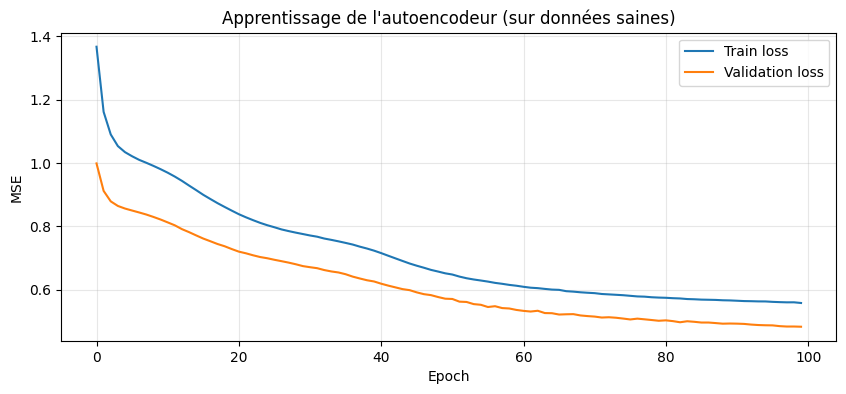

In [13]:
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,   # entrée = sortie (on reconstruit)
    epochs=100,
    batch_size=16,
    validation_split=0.15,
    verbose=1
)

# Courbe de loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title("Apprentissage de l'autoencodeur (sur données saines)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

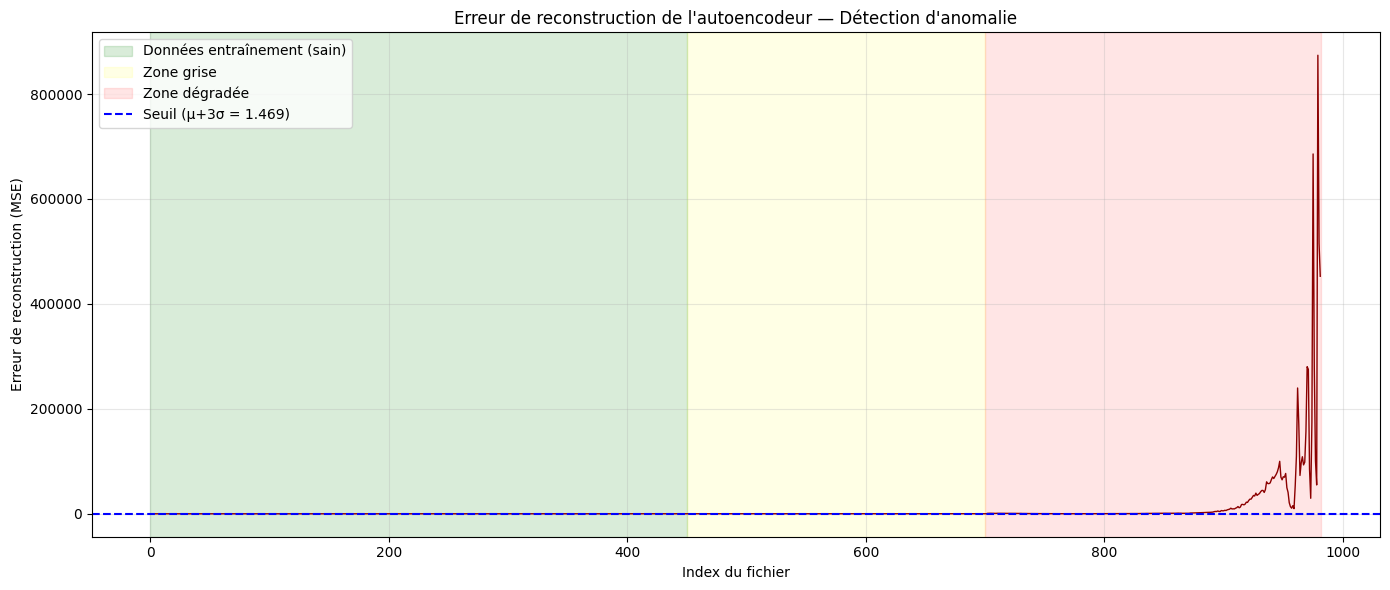

Seuil : 1.4691
Nombre de fichiers détectés comme anormaux : 454 / 982
Premier fichier détecté comme anormal : #0


In [14]:
# Reconstruire TOUT le dataset
X_all_pred = autoencoder.predict(X_all_scaled, verbose=0)

# Erreur de reconstruction = MSE par fichier
reconstruction_error = np.mean((X_all_scaled - X_all_pred) ** 2, axis=1)

# Tracer l'erreur de reconstruction
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(reconstruction_error, color='darkred', linewidth=1)
ax.axvspan(0, TRAIN_END, alpha=0.15, color='green', label='Données entraînement (sain)')
ax.axvspan(TRAIN_END, 700, alpha=0.1, color='yellow', label='Zone grise')
ax.axvspan(700, len(reconstruction_error), alpha=0.1, color='red', label='Zone dégradée')

# Seuil = moyenne + 3 écarts-types sur les données saines
threshold = reconstruction_error[:TRAIN_END].mean() + 3 * reconstruction_error[:TRAIN_END].std()
ax.axhline(y=threshold, color='blue', linestyle='--', label=f'Seuil (μ+3σ = {threshold:.3f})')

ax.set_title("Erreur de reconstruction de l'autoencodeur — Détection d'anomalie")
ax.set_xlabel("Index du fichier")
ax.set_ylabel("Erreur de reconstruction (MSE)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistiques
n_anomalies = np.sum(reconstruction_error > threshold)
print(f"Seuil : {threshold:.4f}")
print(f"Nombre de fichiers détectés comme anormaux : {n_anomalies} / {len(reconstruction_error)}")
first_anomaly = np.argmax(reconstruction_error > threshold)
print(f"Premier fichier détecté comme anormal : #{first_anomaly}")

In [15]:
# Examiner l'erreur de reconstruction sur la zone saine uniquement
err_sain = reconstruction_error[:TRAIN_END]
print("=== Erreur sur zone saine (fichiers 0-450) ===")
print(f"Min    : {err_sain.min():.4f}")
print(f"Max    : {err_sain.max():.4f}")
print(f"Moyenne: {err_sain.mean():.4f}")
print(f"Médiane: {np.median(err_sain):.4f}")
print(f"Std    : {err_sain.std():.4f}")

print("\n=== Erreur globale ===")
print(f"Min : {reconstruction_error.min():.4f}")
print(f"Max : {reconstruction_error.max():.4f}")

# Les 10 features et leur ordre de grandeur
print("\n=== Échelle des features (avant normalisation) ===")
print(df.describe().T[['mean', 'std', 'min', 'max']])

=== Erreur sur zone saine (fichiers 0-450) ===
Min    : 0.0904
Max    : 3.3457
Moyenne: 0.5453
Médiane: 0.4853
Std    : 0.3080

=== Erreur globale ===
Min : 0.0904
Max : 873907.3125

=== Échelle des features (avant normalisation) ===
                   mean       std       min        max
rms            0.106323  0.058092  0.074007   0.725001
peak           0.556121  0.387683  0.315000   5.000000
p2p            1.056872  0.739339  0.615000   9.998000
kurtosis       0.826758  0.959449 -0.264541  14.110009
skew          -0.034103  0.086218 -0.766067   0.120611
crest          5.178664  0.566546  3.449687   9.333270
std            0.106302  0.058097  0.073475   0.724996
band_0_100     0.000549  0.000338  0.000393   0.008322
band_200_260   0.000126  0.000269  0.000034   0.006267
band_440_500   0.000188  0.000421  0.000063   0.008147
band_670_730   0.000354  0.001118  0.000018   0.011255
band_900_950   0.000612  0.001575  0.000058   0.015155
band_970_1010  0.002089  0.000243  0.001795   0.007

In [16]:
# === Transformation log + normalisation robuste ===

# Les features d'énergie spectrale varient sur plusieurs ordres de grandeur
# → transformation log. Le +1e-10 évite log(0).
log_features = ['band_0_100', 'band_200_260', 'band_440_500', 
                'band_670_730', 'band_900_950', 'band_970_1010', 'band_HF']

df_transformed = df.copy()
for feat in log_features:
    df_transformed[feat] = np.log10(df[feat] + 1e-10)

# Optionnel : kurtosis aussi très asymétrique, on peut le garder tel quel pour l'instant
print("=== Échelle après transformation log ===")
print(df_transformed.describe().T[['mean', 'std', 'min', 'max']])

=== Échelle après transformation log ===
                   mean       std       min        max
rms            0.106323  0.058092  0.074007   0.725001
peak           0.556121  0.387683  0.315000   5.000000
p2p            1.056872  0.739339  0.615000   9.998000
kurtosis       0.826758  0.959449 -0.264541  14.110009
skew          -0.034103  0.086218 -0.766067   0.120611
crest          5.178664  0.566546  3.449687   9.333270
std            0.106302  0.058097  0.073475   0.724996
band_0_100    -3.277351  0.089786 -3.405967  -2.079754
band_200_260  -4.033265  0.249820 -4.471791  -2.202967
band_440_500  -3.891988  0.255668 -4.201623  -2.088977
band_670_730  -4.186388  0.608931 -4.735788  -1.948642
band_900_950  -3.741880  0.539695 -4.240255  -1.819448
band_970_1010 -2.681540  0.032448 -2.745929  -2.097806
band_HF       -1.836141  0.348118 -2.131069  -0.033548


In [17]:
X_all = df_transformed.values.astype(np.float32)
X_train = X_all[:TRAIN_END]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_all_scaled = scaler.transform(X_all)

print(f"X_train_scaled — moyenne : {X_train_scaled.mean():.3f}, std : {X_train_scaled.std():.3f}")
print(f"X_all_scaled — min : {X_all_scaled.min():.2f}, max : {X_all_scaled.max():.2f}")

X_train_scaled — moyenne : 0.000, std : 1.000
X_all_scaled — min : -28.31, max : 614.41


In [18]:
# Trouver quelle(s) feature(s) produit/produisent les valeurs extrêmes
X_all_check = scaler.transform(df_transformed.values.astype(np.float32))

print("=== Valeur max normalisée par feature ===")
for i, col in enumerate(df_transformed.columns):
    col_max = X_all_check[:, i].max()
    col_min = X_all_check[:, i].min()
    flag = "  ⚠️ EXTRÊME" if (col_max > 30 or col_min < -30) else ""
    print(f"{col:<16} min={col_min:>8.2f}  max={col_max:>8.2f}{flag}")

=== Valeur max normalisée par feature ===
rms              min=   -3.02  max=  614.41  ⚠️ EXTRÊME
peak             min=   -2.24  max=  116.22  ⚠️ EXTRÊME
p2p              min=   -2.42  max=  148.18  ⚠️ EXTRÊME
kurtosis         min=   -7.10  max=  141.37  ⚠️ EXTRÊME
skew             min=  -28.31  max=    4.28
crest            min=   -3.55  max=    8.21
std              min=   -3.48  max=  611.31  ⚠️ EXTRÊME
band_0_100       min=   -2.47  max=   26.08
band_200_260     min=   -2.30  max=   11.11
band_440_500     min=   -2.66  max=   21.29
band_670_730     min=   -3.16  max=   41.58  ⚠️ EXTRÊME
band_900_950     min=   -2.96  max=   37.23  ⚠️ EXTRÊME
band_970_1010    min=   -2.75  max=   25.54
band_HF          min=   -3.23  max=  133.26  ⚠️ EXTRÊME


In [19]:
from sklearn.preprocessing import RobustScaler

# On garde la transformation log sur les bandes (déjà bénéfique)
# df_transformed existe déjà avec les band_* en log

X_all = df_transformed.values.astype(np.float32)
X_train = X_all[:TRAIN_END]

# RobustScaler : médiane + IQR, insensible aux valeurs extrêmes
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_all_scaled = scaler.transform(X_all)

# Clipping à ±10 : borne les valeurs extrêmes sans perdre l'info "anormal"
CLIP = 10.0
X_train_scaled = np.clip(X_train_scaled, -CLIP, CLIP)
X_all_scaled = np.clip(X_all_scaled, -CLIP, CLIP)

print(f"Après RobustScaler + clipping ±{CLIP} :")
print(f"  X_train_scaled — min : {X_train_scaled.min():.2f}, max : {X_train_scaled.max():.2f}")
print(f"  X_all_scaled   — min : {X_all_scaled.min():.2f}, max : {X_all_scaled.max():.2f}")
print(f"  (les deux doivent être dans [-10, 10])")

# Vérif par feature
print("\n=== Plage par feature (zone saine) ===")
for i, col in enumerate(df_transformed.columns):
    cmin, cmax = X_train_scaled[:TRAIN_END, i].min(), X_train_scaled[:TRAIN_END, i].max()
    print(f"{col:<16} [{cmin:>6.2f}, {cmax:>6.2f}]")

Après RobustScaler + clipping ±10.0 :
  X_train_scaled — min : -3.27, max : 6.19
  X_all_scaled   — min : -10.00, max : 10.00
  (les deux doivent être dans [-10, 10])

=== Plage par feature (zone saine) ===
rms              [ -2.25,   2.10]
peak             [ -1.61,   4.14]
p2p              [ -1.87,   5.71]
kurtosis         [ -2.12,   6.19]
skew             [ -3.27,   2.30]
crest            [ -1.51,   3.93]
std              [ -2.62,   2.11]
band_0_100       [ -1.72,   3.13]
band_200_260     [ -1.67,   2.04]
band_440_500     [ -1.91,   2.31]
band_670_730     [ -2.26,   1.99]
band_900_950     [ -2.11,   2.11]
band_970_1010    [ -2.10,   2.27]
band_HF          [ -2.15,   1.51]


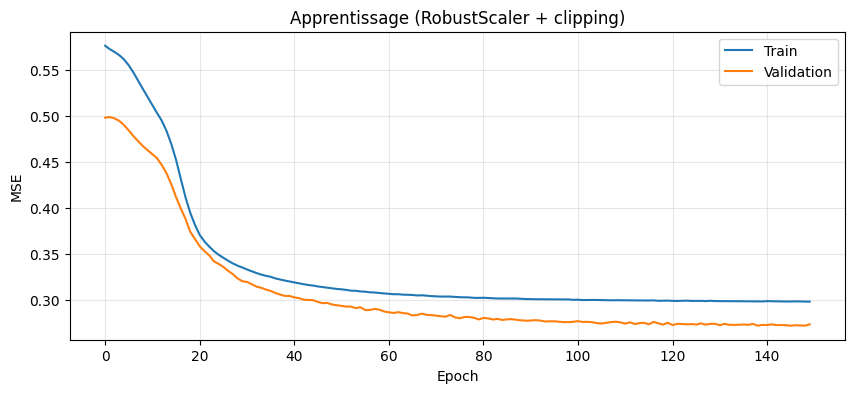

Loss finale : train=0.2983, val=0.2737


In [20]:
# Réentraîner sur les données proprement normalisées
autoencoder = build_autoencoder(n_features)
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=150, batch_size=16, validation_split=0.15, verbose=0
)

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Apprentissage (RobustScaler + clipping)")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()
print(f"Loss finale : train={history.history['loss'][-1]:.4f}, val={history.history['val_loss'][-1]:.4f}")

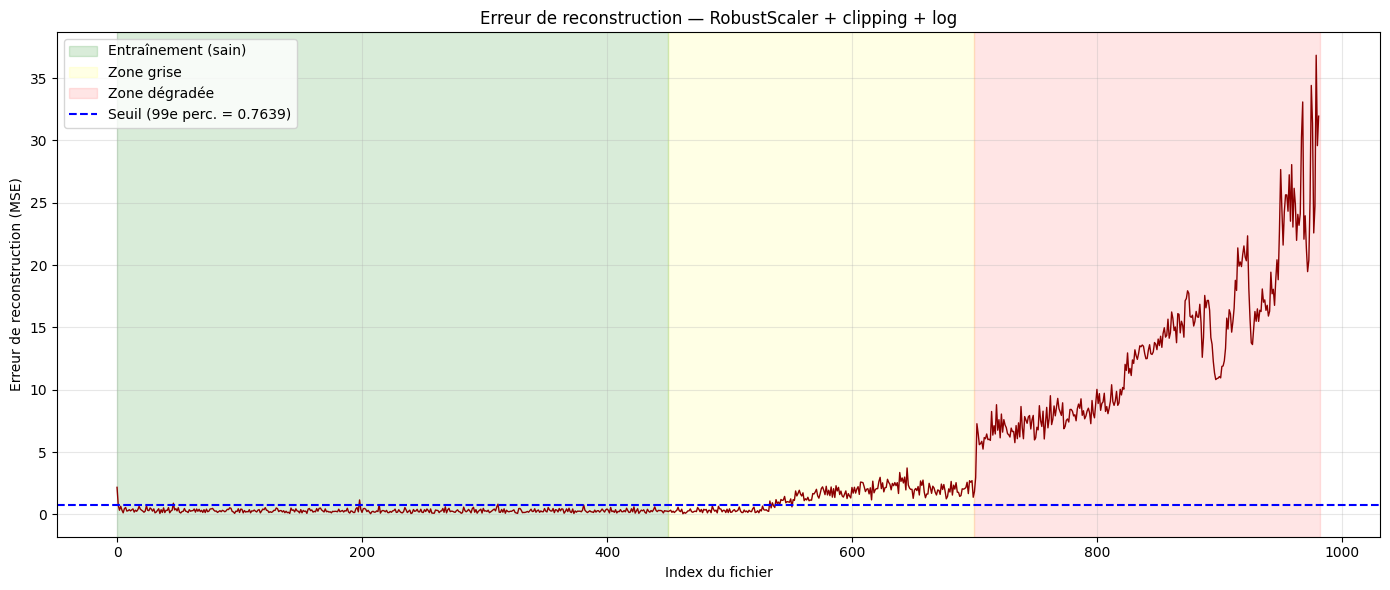

Seuil : 0.7639
Anomalies détectées : 450 / 982
Premier fichier anormal détecté : #0
Fausses alarmes en zone saine : 5 / 450


In [21]:
# Détection
X_all_pred = autoencoder.predict(X_all_scaled, verbose=0)
reconstruction_error = np.mean((X_all_scaled - X_all_pred) ** 2, axis=1)
threshold = np.percentile(reconstruction_error[:TRAIN_END], 99)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(reconstruction_error, color='darkred', linewidth=1)
ax.axvspan(0, TRAIN_END, alpha=0.15, color='green', label='Entraînement (sain)')
ax.axvspan(TRAIN_END, 700, alpha=0.1, color='yellow', label='Zone grise')
ax.axvspan(700, len(reconstruction_error), alpha=0.1, color='red', label='Zone dégradée')
ax.axhline(y=threshold, color='blue', linestyle='--', label=f'Seuil (99e perc. = {threshold:.4f})')
ax.set_title("Erreur de reconstruction — RobustScaler + clipping + log")
ax.set_xlabel("Index du fichier"); ax.set_ylabel("Erreur de reconstruction (MSE)")
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

n_anomalies = np.sum(reconstruction_error > threshold)
first_anomaly = np.argmax(reconstruction_error > threshold)
false_alarms = np.sum(reconstruction_error[:TRAIN_END] > threshold)
print(f"Seuil : {threshold:.4f}")
print(f"Anomalies détectées : {n_anomalies} / {len(reconstruction_error)}")
print(f"Premier fichier anormal détecté : #{first_anomaly}")
print(f"Fausses alarmes en zone saine : {false_alarms} / {TRAIN_END}")

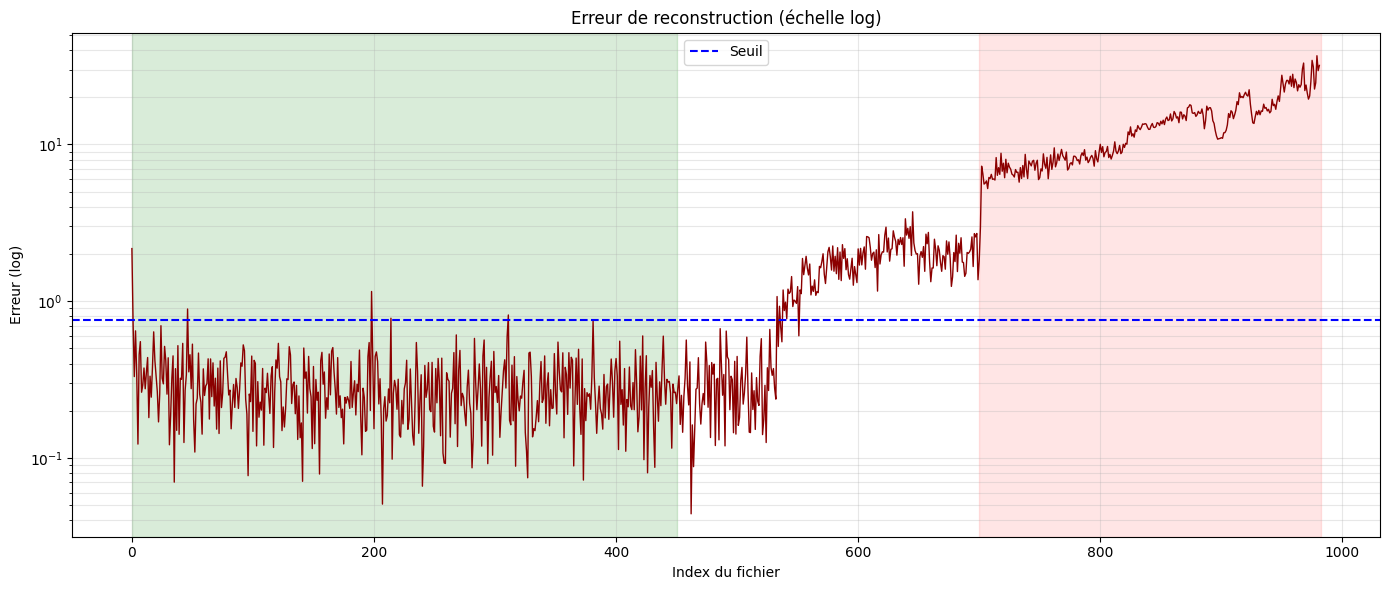

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.semilogy(reconstruction_error, color='darkred', linewidth=1)
ax.axvspan(0, TRAIN_END, alpha=0.15, color='green')
ax.axvspan(700, len(reconstruction_error), alpha=0.1, color='red')
ax.axhline(y=threshold, color='blue', linestyle='--', label=f'Seuil')
ax.set_title("Erreur de reconstruction (échelle log)")
ax.set_xlabel("Index du fichier"); ax.set_ylabel("Erreur (log)")
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

In [23]:
# Analyser les fausses alarmes selon différents seuils
print("=== Choix du seuil : analyse du compromis ===\n")
print(f"{'Méthode':<35} {'Seuil':<10} {'Fausses alarmes':<18} {'1er détecté'}")
print("-" * 80)

err_sain = reconstruction_error[:TRAIN_END]

methods = {
    "99e percentile (sain)":      np.percentile(err_sain, 99),
    "99.5e percentile (sain)":    np.percentile(err_sain, 99.5),
    "100e percentile = max sain": err_sain.max(),
    "Max sain × 1.5 (marge)":     err_sain.max() * 1.5,
    "Max sain × 2 (ta proposition)": err_sain.max() * 2,
}

for name, thr in methods.items():
    fa = np.sum(err_sain > thr)
    first = np.argmax(reconstruction_error > thr)
    print(f"{name:<35} {thr:<10.4f} {fa:<18} #{first}")

=== Choix du seuil : analyse du compromis ===

Méthode                             Seuil      Fausses alarmes    1er détecté
--------------------------------------------------------------------------------
99e percentile (sain)               0.7639     5                  #0
99.5e percentile (sain)             0.8737     3                  #0
100e percentile = max sain          2.1667     0                  #576
Max sain × 1.5 (marge)              3.2501     0                  #639
Max sain × 2 (ta proposition)       4.3334     0                  #702


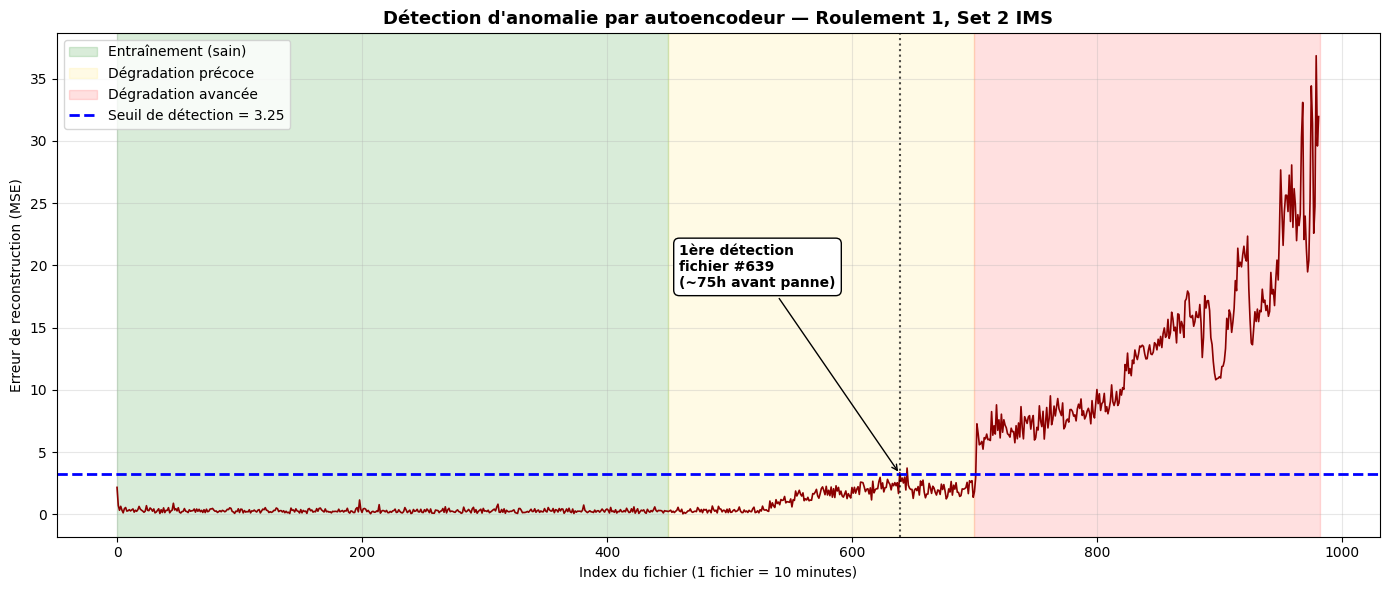

Modèle baseline finalisé :
  Seuil : 3.2501
  Première détection : fichier #639
  Anticipation : ~57 heures avant la fin
  Fausses alarmes : 0


In [24]:
# Seuil final retenu
MARGIN = 1.5
threshold = reconstruction_error[:TRAIN_END].max() * MARGIN

# Visualisation finale propre (figure pour le mémoire)
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(reconstruction_error, color='darkred', linewidth=1.2)
ax.axvspan(0, TRAIN_END, alpha=0.15, color='green', label='Entraînement (sain)')
ax.axvspan(TRAIN_END, 700, alpha=0.1, color='gold', label='Dégradation précoce')
ax.axvspan(700, len(reconstruction_error), alpha=0.12, color='red', label='Dégradation avancée')
ax.axhline(y=threshold, color='blue', linestyle='--', linewidth=2,
           label=f'Seuil de détection = {threshold:.2f}')

first = np.argmax(reconstruction_error > threshold)
ax.axvline(x=first, color='black', linestyle=':', alpha=0.7)
ax.annotate(f'1ère détection\nfichier #{first}\n(~75h avant panne)',
            xy=(first, threshold), xytext=(first-180, threshold+15),
            fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black'))

ax.set_title("Détection d'anomalie par autoencodeur — Roulement 1, Set 2 IMS", fontsize=13, fontweight='bold')
ax.set_xlabel("Index du fichier (1 fichier = 10 minutes)")
ax.set_ylabel("Erreur de reconstruction (MSE)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('detection_baseline.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Modèle baseline finalisé :")
print(f"  Seuil : {threshold:.4f}")
print(f"  Première détection : fichier #{first}")
print(f"  Anticipation : ~{(982-first)*10/60:.0f} heures avant la fin")
print(f"  Fausses alarmes : {np.sum(reconstruction_error[:TRAIN_END] > threshold)}")

In [25]:
# Sauvegarder le modèle et les objets de preprocessing (essentiel pour la suite hls4ml)
import joblib

autoencoder.save('autoencoder_baseline.keras')
joblib.dump(scaler, 'scaler.pkl')
np.save('reconstruction_error_baseline.npy', reconstruction_error)

# Sauvegarder aussi les hyperparamètres / config
config = {
    'TRAIN_END': TRAIN_END,
    'MARGIN': MARGIN,
    'threshold': float(threshold),
    'n_features': n_features,
    'log_features': log_features,
    'first_detection': int(first),
}
import json
with open('baseline_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Sauvegardé :")
print("  - autoencoder_baseline.keras (le modèle)")
print("  - scaler.pkl (le RobustScaler)")
print("  - baseline_config.json (la config)")
print("  - detection_baseline.png (figure mémoire)")

Sauvegardé :
  - autoencoder_baseline.keras (le modèle)
  - scaler.pkl (le RobustScaler)
  - baseline_config.json (la config)
  - detection_baseline.png (figure mémoire)


In [26]:
# Examiner les tout premiers fichiers en détail
print("=== Régime de démarrage : 20 premiers fichiers (Bearing 1) ===")
print(f"{'Fichier':<10} {'RMS':<10} {'Kurtosis':<10} {'band_HF':<12}")
print("-" * 45)
for i in range(20):
    print(f"#{i:<9} {df.iloc[i]['rms']:<10.4f} {df.iloc[i]['kurtosis']:<10.4f} {df.iloc[i]['band_HF']:<12.6f}")

# Statistiques : comparer les 20 premiers vs les fichiers 50-450
print("\n=== Comparaison statistique ===")
for feat in ['rms', 'kurtosis', 'crest', 'band_HF']:
    early = df.iloc[:20][feat]
    stable = df.iloc[50:450][feat]
    print(f"{feat:<12} | 20 premiers: moy={early.mean():.4f} std={early.std():.4f} "
          f"| 50-450 stable: moy={stable.mean():.4f} std={stable.std():.4f}")

=== Régime de démarrage : 20 premiers fichiers (Bearing 1) ===
Fichier    RMS        Kurtosis   band_HF     
---------------------------------------------
#0         0.0742     0.6288     0.007395    
#1         0.0754     0.6483     0.007982    
#2         0.0762     0.5135     0.007997    
#3         0.0787     1.1580     0.008687    
#4         0.0785     0.6032     0.008551    
#5         0.0783     0.4561     0.008577    
#6         0.0786     0.4786     0.008467    
#7         0.0778     0.4720     0.008357    
#8         0.0790     0.4045     0.008549    
#9         0.0757     0.3252     0.007684    
#10        0.0792     0.4552     0.008619    
#11        0.0776     0.6415     0.008245    
#12        0.0774     0.3647     0.008164    
#13        0.0799     0.5983     0.008919    
#14        0.0792     0.5511     0.008600    
#15        0.0787     0.5531     0.008555    
#16        0.0785     0.4800     0.008352    
#17        0.0776     0.4477     0.008124    
#18        0.0778

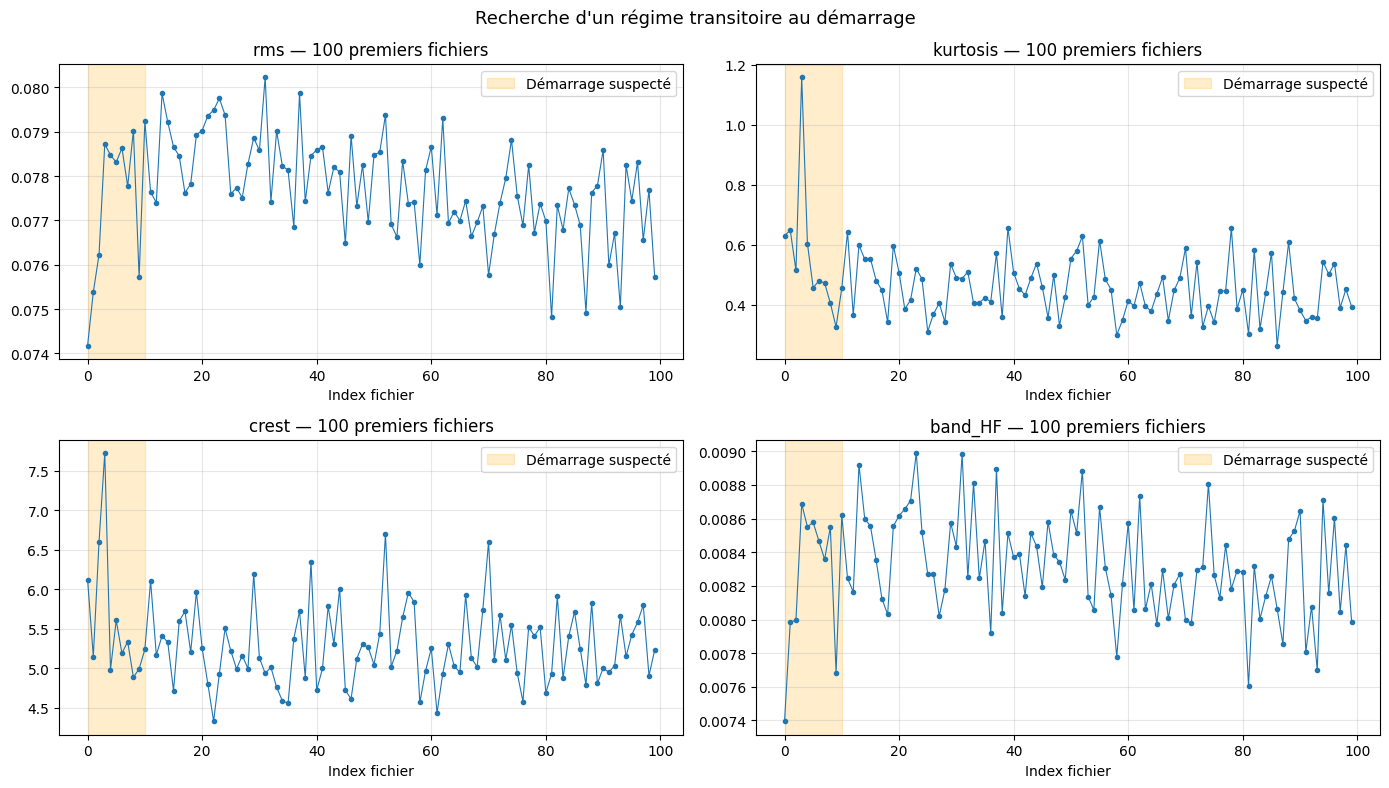

In [27]:
# Visualiser le tout début pour voir le transitoire
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, feat in zip(axes.flat, ['rms', 'kurtosis', 'crest', 'band_HF']):
    ax.plot(df[feat].values[:100], 'o-', markersize=3, linewidth=0.8)
    ax.axvspan(0, 10, alpha=0.2, color='orange', label='Démarrage suspecté')
    ax.set_title(f'{feat} — 100 premiers fichiers')
    ax.set_xlabel('Index fichier')
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle("Recherche d'un régime transitoire au démarrage", fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
# === Paramètres ===
WARMUP = 15        # Régime transitoire de démarrage exclu (confirmé par diagnostic)
TRAIN_END = 450    # Fin de la zone d'entraînement saine
MARGIN = 1.5       # Marge de sécurité sur le seuil

Fichiers exclus (démarrage) : 0 à 14
Entraînement (sain stable)  : 15 à 449  (435 fichiers)
X_all_scaled — min: -10.00, max: 10.00

Loss finale : train=0.2926, val=0.2699


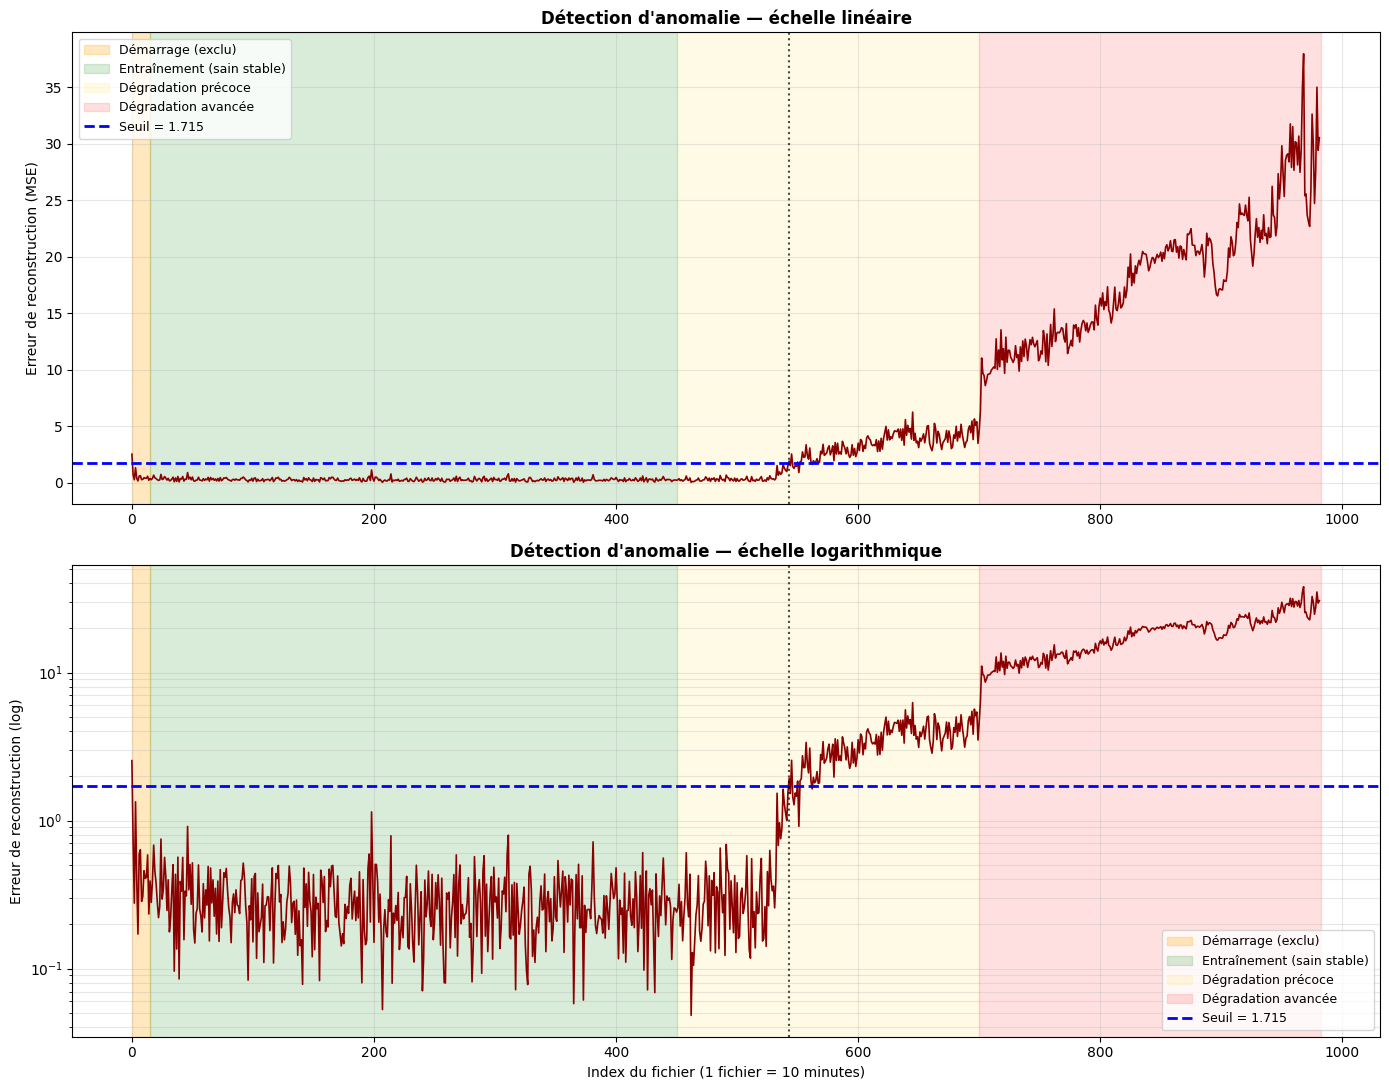


Seuil de détection           : 1.7149
Fausses alarmes (sain stable): 0 / 435
Premier fichier détecté      : #543
Anticipation                 : ~73 h (~3.0 jours) avant la fin


In [29]:
# ============================================================
#  AUTOENCODEUR — DÉTECTION D'ANOMALIE (pipeline complet)
#  Warmup exclu + log + RobustScaler + clipping
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from tensorflow import keras

# ---------- Paramètres ----------
WARMUP    = 15      # Régime transitoire de démarrage exclu (confirmé par diagnostic)
TRAIN_END = 450     # Fin de la zone d'entraînement saine
MARGIN    = 1.5     # Marge de sécurité sur le seuil
CLIP      = 10.0    # Borne des valeurs normalisées

# ---------- Préparation des données ----------
# df_transformed : features avec band_* déjà en log10 (cellules précédentes)
X_all   = df_transformed.values.astype(np.float32)
X_train = X_all[WARMUP:TRAIN_END]          # régime sain STABLE uniquement

scaler = RobustScaler()
X_train_scaled = np.clip(scaler.fit_transform(X_train), -CLIP, CLIP)
X_all_scaled   = np.clip(scaler.transform(X_all),       -CLIP, CLIP)

print(f"Fichiers exclus (démarrage) : 0 à {WARMUP-1}")
print(f"Entraînement (sain stable)  : {WARMUP} à {TRAIN_END-1}  ({X_train.shape[0]} fichiers)")
print(f"X_all_scaled — min: {X_all_scaled.min():.2f}, max: {X_all_scaled.max():.2f}\n")

# ---------- Entraînement ----------
autoencoder = build_autoencoder(n_features)
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=150, batch_size=16, validation_split=0.15, verbose=0
)
print(f"Loss finale : train={history.history['loss'][-1]:.4f}, "
      f"val={history.history['val_loss'][-1]:.4f}")

# ---------- Détection ----------
X_all_pred = autoencoder.predict(X_all_scaled, verbose=0)
reconstruction_error = np.mean((X_all_scaled - X_all_pred) ** 2, axis=1)

err_sain_stable = reconstruction_error[WARMUP:TRAIN_END]
threshold = err_sain_stable.max() * MARGIN
first = np.argmax(reconstruction_error[WARMUP:] > threshold) + WARMUP

# ---------- Figure double : linéaire + log ----------
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

def draw_zones(ax):
    ax.axvspan(0, WARMUP, alpha=0.25, color='orange', label='Démarrage (exclu)')
    ax.axvspan(WARMUP, TRAIN_END, alpha=0.15, color='green', label='Entraînement (sain stable)')
    ax.axvspan(TRAIN_END, 700, alpha=0.10, color='gold', label='Dégradation précoce')
    ax.axvspan(700, len(reconstruction_error), alpha=0.12, color='red', label='Dégradation avancée')
    ax.axhline(y=threshold, color='blue', linestyle='--', linewidth=2,
               label=f'Seuil = {threshold:.3f}')
    ax.axvline(x=first, color='black', linestyle=':', alpha=0.7)

# --- Linéaire ---
ax = axes[0]
ax.plot(reconstruction_error, color='darkred', linewidth=1.2)
draw_zones(ax)
ax.set_title("Détection d'anomalie — échelle linéaire", fontsize=12, fontweight='bold')
ax.set_ylabel("Erreur de reconstruction (MSE)")
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# --- Logarithmique ---
ax = axes[1]
ax.semilogy(reconstruction_error, color='darkred', linewidth=1.2)
draw_zones(ax)
ax.set_title("Détection d'anomalie — échelle logarithmique", fontsize=12, fontweight='bold')
ax.set_xlabel("Index du fichier (1 fichier = 10 minutes)")
ax.set_ylabel("Erreur de reconstruction (log)")
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('detection_baseline_final.png', dpi=200, bbox_inches='tight')
plt.show()

# ---------- Statistiques ----------
fa = np.sum(err_sain_stable > threshold)
anticipation_h = (len(reconstruction_error) - first) * 10 / 60
print(f"\n{'='*50}")
print(f"Seuil de détection           : {threshold:.4f}")
print(f"Fausses alarmes (sain stable): {fa} / {len(err_sain_stable)}")
print(f"Premier fichier détecté      : #{first}")
print(f"Anticipation                 : ~{anticipation_h:.0f} h "
      f"(~{anticipation_h/24:.1f} jours) avant la fin")
print(f"{'='*50}")

In [30]:
# Analyse fine : impact de la marge sur détection vs fausses alarmes
print("=== Compromis marge / détection / fausses alarmes ===\n")
print(f"{'Marge':<8} {'Seuil':<10} {'Fausses alarmes':<18} {'1er détecté':<14} {'Anticipation'}")
print("-" * 75)

err_sain = reconstruction_error[WARMUP:TRAIN_END]
max_sain = err_sain.max()

for margin in [1.0, 1.1, 1.2, 1.3, 1.5, 1.8, 2.0, 2.5, 3.0]:
    thr = max_sain * margin
    fa = np.sum(err_sain > thr)
    # premier dépassement après le warmup
    detected = np.where(reconstruction_error[WARMUP:] > thr)[0]
    first = detected[0] + WARMUP if len(detected) > 0 else -1
    if first > 0:
        antic_h = (len(reconstruction_error) - first) * 10 / 60
        print(f"{margin:<8} {thr:<10.4f} {fa:<18} #{first:<13} ~{antic_h:.0f}h ({antic_h/24:.1f}j)")
    else:
        print(f"{margin:<8} {thr:<10.4f} {fa:<18} aucune détection")
        

=== Compromis marge / détection / fausses alarmes ===

Marge    Seuil      Fausses alarmes    1er détecté    Anticipation
---------------------------------------------------------------------------
1.0      1.1432     0                  #533           ~75h (3.1j)
1.1      1.2576     0                  #533           ~75h (3.1j)
1.2      1.3719     0                  #533           ~75h (3.1j)
1.3      1.4862     0                  #533           ~75h (3.1j)
1.5      1.7149     0                  #543           ~73h (3.0j)
1.8      2.0578     0                  #545           ~73h (3.0j)
2.0      2.2865     0                  #545           ~73h (3.0j)
2.5      2.8581     0                  #557           ~71h (3.0j)
3.0      3.4297     0                  #581           ~67h (2.8j)


In [31]:
import joblib, json

# Seuil final retenu
MARGIN = 1.5
threshold = reconstruction_error[WARMUP:TRAIN_END].max() * MARGIN
first = np.where(reconstruction_error[WARMUP:] > threshold)[0][0] + WARMUP

# Sauvegarde du modèle et du preprocessing
autoencoder.save('autoencoder_baseline.keras')
joblib.dump(scaler, 'scaler_baseline.pkl')
np.save('reconstruction_error_baseline.npy', reconstruction_error)

# Configuration complète
config = {
    'WARMUP': WARMUP,
    'TRAIN_END': TRAIN_END,
    'MARGIN': MARGIN,
    'threshold': float(threshold),
    'n_features': int(n_features),
    'log_features': log_features,
    'clip': CLIP,
    'first_detection': int(first),
    'anticipation_hours': float((len(reconstruction_error) - first) * 10 / 60),
    'false_alarms': 0,
    'architecture': '14-8-4-3-4-8-14',
    'total_params': 353,
}
with open('baseline_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("=== BASELINE FIGÉ ===")
for k, v in config.items():
    print(f"  {k:<22}: {v}")
print("\nFichiers sauvegardés :")
print("  - autoencoder_baseline.keras")
print("  - scaler_baseline.pkl")
print("  - baseline_config.json")
print("  - detection_baseline_final.png")

=== BASELINE FIGÉ ===
  WARMUP                : 15
  TRAIN_END             : 450
  MARGIN                : 1.5
  threshold             : 1.7148510217666626
  n_features            : 14
  log_features          : ['band_0_100', 'band_200_260', 'band_440_500', 'band_670_730', 'band_900_950', 'band_970_1010', 'band_HF']
  clip                  : 10.0
  first_detection       : 543
  anticipation_hours    : 73.16666666666667
  false_alarms          : 0
  architecture          : 14-8-4-3-4-8-14
  total_params          : 353

Fichiers sauvegardés :
  - autoencoder_baseline.keras
  - scaler_baseline.pkl
  - baseline_config.json
  - detection_baseline_final.png


In [32]:
# Cellule 1 — Imports et vérification QKeras
import numpy as np
import matplotlib.pyplot as plt
import joblib, json
from tensorflow import keras

# QKeras : couches quantifiées
from qkeras import QDense, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu

print("QKeras importé avec succès")

# Recharger le baseline et sa config
with open('baseline_config.json') as f:
    config = json.load(f)
print("Config baseline :", config)

scaler = joblib.load('scaler_baseline.pkl')

# Re-préparer les données (identique au baseline)
X_all = df_transformed.values.astype(np.float32)
WARMUP    = config['WARMUP']
TRAIN_END = config['TRAIN_END']
CLIP      = config['clip']

X_train_scaled = np.clip(scaler.transform(X_all[WARMUP:TRAIN_END]), -CLIP, CLIP)
X_all_scaled   = np.clip(scaler.transform(X_all), -CLIP, CLIP)
n_features = X_train_scaled.shape[1]
print(f"Données prêtes : train={X_train_scaled.shape}, all={X_all_scaled.shape}")

QKeras importé avec succès
Config baseline : {'WARMUP': 15, 'TRAIN_END': 450, 'MARGIN': 1.5, 'threshold': 1.7148510217666626, 'n_features': 14, 'log_features': ['band_0_100', 'band_200_260', 'band_440_500', 'band_670_730', 'band_900_950', 'band_970_1010', 'band_HF'], 'clip': 10.0, 'first_detection': 543, 'anticipation_hours': 73.16666666666667, 'false_alarms': 0, 'architecture': '14-8-4-3-4-8-14', 'total_params': 353}
Données prêtes : train=(435, 14), all=(982, 14)


In [33]:
# Cellule 2 — Construire l'autoencodeur QUANTIFIÉ
# On commence avec une quantization "raisonnable" : 8 bits
# quantized_bits(bits, integer) : nb bits total, nb bits partie entière

def build_qautoencoder(n_features, bits=8, int_bits=2):
    q = f"quantized_bits({bits},{int_bits},alpha=1)"      # pour les poids
    qa = f"quantized_relu({bits},{int_bits})"             # pour les activations ReLU

    model = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        QDense(8, kernel_quantizer=q, bias_quantizer=q, name='enc1'),
        QActivation(qa, name='enc1_act'),
        QDense(4, kernel_quantizer=q, bias_quantizer=q, name='enc2'),
        QActivation(qa, name='enc2_act'),
        QDense(3, kernel_quantizer=q, bias_quantizer=q, name='bottleneck'),
        QActivation(qa, name='bottleneck_act'),
        QDense(4, kernel_quantizer=q, bias_quantizer=q, name='dec1'),
        QActivation(qa, name='dec1_act'),
        QDense(8, kernel_quantizer=q, bias_quantizer=q, name='dec2'),
        QActivation(qa, name='dec2_act'),
        # Dernière couche : on quantifie les poids mais sortie linéaire
        QDense(n_features, kernel_quantizer=q, bias_quantizer=q, name='output'),
    ])
    return model

qmodel = build_qautoencoder(n_features, bits=8, int_bits=2)
qmodel.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
qmodel.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 enc1 (QDense)               (None, 8)                 120       
                                                                 
 enc1_act (QActivation)      (None, 8)                 0         
                                                                 
 enc2 (QDense)               (None, 4)                 36        
                                                                 
 enc2_act (QActivation)      (None, 4)                 0         
                                                                 
 bottleneck (QDense)         (None, 3)                 15        
                                                                 
 bottleneck_act (QActivatio  (None, 3)                 0         
 n)                                                              
                                                      

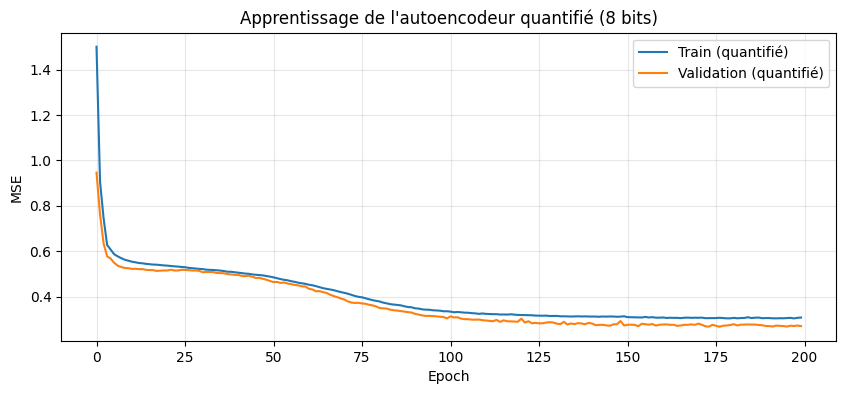

Loss finale quantifiée : train=0.3076, val=0.2696


In [34]:
# Cellule 3 — Entraîner le modèle quantifié
history_q = qmodel.fit(
    X_train_scaled, X_train_scaled,
    epochs=200,            # un peu plus d'epochs : la quantization demande plus d'apprentissage
    batch_size=16,
    validation_split=0.15,
    verbose=0
)

plt.figure(figsize=(10, 4))
plt.plot(history_q.history['loss'], label='Train (quantifié)')
plt.plot(history_q.history['val_loss'], label='Validation (quantifié)')
plt.title("Apprentissage de l'autoencodeur quantifié (8 bits)")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()
print(f"Loss finale quantifiée : train={history_q.history['loss'][-1]:.4f}, "
      f"val={history_q.history['val_loss'][-1]:.4f}")

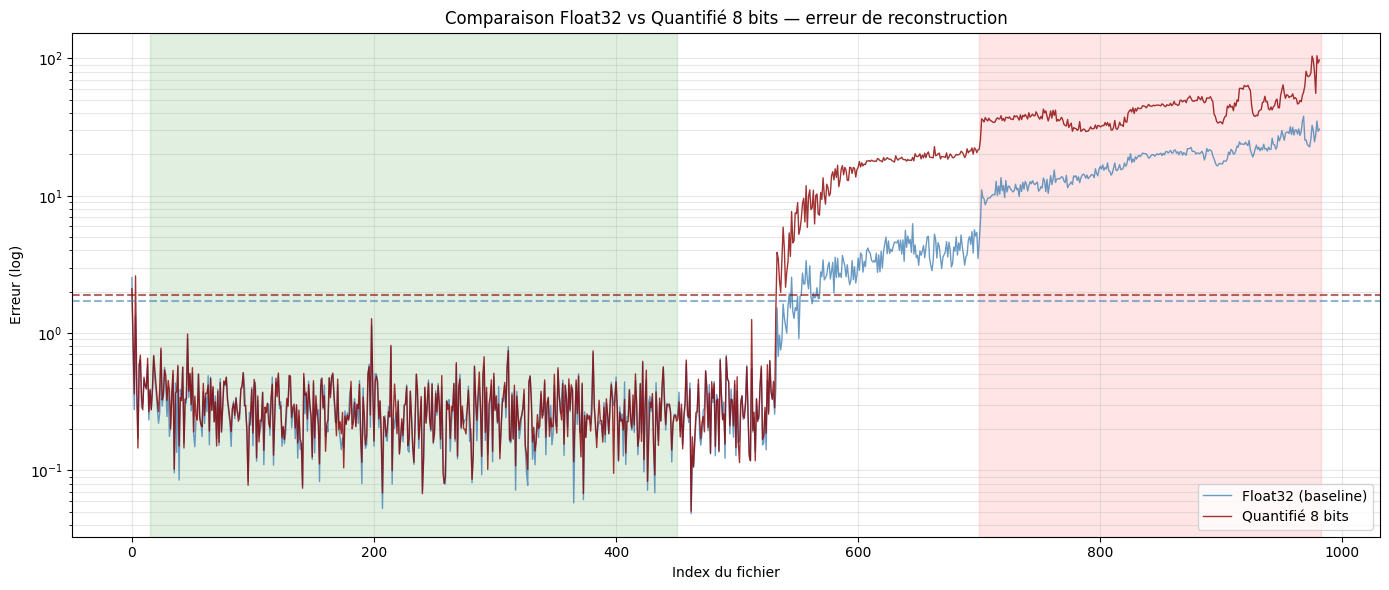

=== COMPARAISON ===
Métrique                     Float32         Quantifié 8b
----------------------------------------------------------
Seuil                        1.7149          1.9113
1er fichier détecté          #543            #533
Fausses alarmes              0               0
Anticipation (h)             73              75


In [35]:
# Cellule 4 — Comparer float32 vs quantifié 8 bits
# Recharger l'erreur du baseline float32
err_float = np.load('reconstruction_error_baseline.npy')

# Erreur du modèle quantifié
X_all_pred_q = qmodel.predict(X_all_scaled, verbose=0)
err_quant = np.mean((X_all_scaled - X_all_pred_q) ** 2, axis=1)

# Seuils respectifs (même méthode : max sain stable × marge)
MARGIN = config['MARGIN']
thr_float = err_float[WARMUP:TRAIN_END].max() * MARGIN
thr_quant = err_quant[WARMUP:TRAIN_END].max() * MARGIN

first_float = np.where(err_float[WARMUP:] > thr_float)[0][0] + WARMUP
first_quant = np.where(err_quant[WARMUP:] > thr_quant)[0][0] + WARMUP

fig, ax = plt.subplots(figsize=(14, 6))
ax.semilogy(err_float, color='steelblue', linewidth=1, label='Float32 (baseline)', alpha=0.8)
ax.semilogy(err_quant, color='darkred', linewidth=1, label='Quantifié 8 bits', alpha=0.8)
ax.axvspan(WARMUP, TRAIN_END, alpha=0.12, color='green')
ax.axvspan(700, len(err_quant), alpha=0.10, color='red')
ax.axhline(thr_float, color='steelblue', linestyle='--', alpha=0.6)
ax.axhline(thr_quant, color='darkred', linestyle='--', alpha=0.6)
ax.set_title("Comparaison Float32 vs Quantifié 8 bits — erreur de reconstruction")
ax.set_xlabel("Index du fichier"); ax.set_ylabel("Erreur (log)")
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('comparaison_float_vs_quant.png', dpi=200, bbox_inches='tight')
plt.show()

print("=== COMPARAISON ===")
print(f"{'Métrique':<28} {'Float32':<15} {'Quantifié 8b'}")
print("-" * 58)
print(f"{'Seuil':<28} {thr_float:<15.4f} {thr_quant:.4f}")
print(f"{'1er fichier détecté':<28} #{first_float:<14} #{first_quant}")
fa_f = np.sum(err_float[WARMUP:TRAIN_END] > thr_float)
fa_q = np.sum(err_quant[WARMUP:TRAIN_END] > thr_quant)
print(f"{'Fausses alarmes':<28} {fa_f:<15} {fa_q}")
ant_f = (len(err_float)-first_float)*10/60
ant_q = (len(err_quant)-first_quant)*10/60
print(f"{'Anticipation (h)':<28} {ant_f:<15.0f} {ant_q:.0f}")

In [36]:
qmodel.save('qautoencoder_8bit.keras')

import json
qconfig = {
    'bits': 8,
    'int_bits': 2,
    'threshold': float(thr_quant),
    'first_detection': int(first_quant),
    'false_alarms': 0,
    'anticipation_hours': float((len(err_quant)-first_quant)*10/60),
}
with open('qconfig_8bit.json', 'w') as f:
    json.dump(qconfig, f, indent=2)

print("Modèle quantifié 8 bits sauvegardé :")
print("  - qautoencoder_8bit.keras")
print("  - qconfig_8bit.json")

Modèle quantifié 8 bits sauvegardé :
  - qautoencoder_8bit.keras
  - qconfig_8bit.json


/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


In [37]:
# ============================================================
#  DESIGN SPACE EXPLORATION — Impact de la précision (bits)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from qkeras import QDense, QActivation
from tensorflow import keras
import time

# --- Configurations à tester ---
# (bits_total, bits_entiers) — on garde 2 bits entiers, on fait varier la précision
configs_to_test = [
    (16, 6),   # quasi-float, référence haute précision
    (8, 2),    # déjà validé
    (6, 2),
    (4, 2),
    (3, 1),
    (2, 1),    # extrême : on s'attend à ce que ça casse
]

def build_qae(n_features, bits, int_bits):
    q  = f"quantized_bits({bits},{int_bits},alpha=1)"
    qa = f"quantized_relu({bits},{int_bits})"
    return keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        QDense(8, kernel_quantizer=q, bias_quantizer=q, name='enc1'),
        QActivation(qa, name='enc1_act'),
        QDense(4, kernel_quantizer=q, bias_quantizer=q, name='enc2'),
        QActivation(qa, name='enc2_act'),
        QDense(3, kernel_quantizer=q, bias_quantizer=q, name='bottleneck'),
        QActivation(qa, name='bn_act'),
        QDense(4, kernel_quantizer=q, bias_quantizer=q, name='dec1'),
        QActivation(qa, name='dec1_act'),
        QDense(8, kernel_quantizer=q, bias_quantizer=q, name='dec2'),
        QActivation(qa, name='dec2_act'),
        QDense(n_features, kernel_quantizer=q, bias_quantizer=q, name='output'),
    ])

results = []

for bits, int_bits in configs_to_test:
    print(f"\n{'='*55}")
    print(f"  Test : {bits} bits (dont {int_bits} entiers)")
    print(f"{'='*55}")

    keras.utils.set_random_seed(42)   # reproductibilité
    m = build_qae(n_features, bits, int_bits)
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

    t0 = time.time()
    m.fit(X_train_scaled, X_train_scaled,
          epochs=200, batch_size=16, validation_split=0.15, verbose=0)
    train_time = time.time() - t0

    # Détection
    err = np.mean((X_all_scaled - m.predict(X_all_scaled, verbose=0))**2, axis=1)
    err_sain = err[WARMUP:TRAIN_END]
    thr = err_sain.max() * MARGIN

    detected = np.where(err[WARMUP:] > thr)[0]
    first = detected[0] + WARMUP if len(detected) else -1
    fa = int(np.sum(err_sain > thr))
    anticip = (len(err) - first) * 10/60 if first > 0 else 0
    # Contraste = ratio erreur médiane dégradée / erreur médiane saine
    contrast = np.median(err[700:]) / np.median(err_sain)

    results.append({
        'bits': bits, 'int_bits': int_bits,
        'first': first, 'fa': fa, 'anticip_h': anticip,
        'contrast': contrast, 'loss_sain': float(err_sain.mean()),
        'train_time': train_time,
    })
    print(f"  1er détecté: #{first} | fausses alarmes: {fa} | "
          f"anticip: {anticip:.0f}h | contraste: {contrast:.1f}")

# --- Tableau récapitulatif ---
print(f"\n\n{'='*75}")
print("RÉCAPITULATIF DESIGN SPACE EXPLORATION")
print(f"{'='*75}")
print(f"{'Bits':<8}{'1er détecté':<14}{'F.alarmes':<12}{'Anticip(h)':<13}{'Contraste':<12}{'Verdict'}")
print("-"*75)
for r in results:
    if r['fa'] == 0 and r['first'] > 0 and abs(r['first']-533) < 30:
        verdict = "✅ OK"
    elif r['fa'] == 0 and r['first'] > 0:
        verdict = "⚠️ détection décalée"
    else:
        verdict = "❌ dégradé"
    print(f"{r['bits']:<8}#{r['first']:<13}{r['fa']:<12}{r['anticip_h']:<13.0f}"
          f"{r['contrast']:<12.1f}{verdict}")


  Test : 16 bits (dont 6 entiers)
  1er détecté: #533 | fausses alarmes: 0 | anticip: 75h | contraste: 148.9

  Test : 8 bits (dont 2 entiers)
  1er détecté: #533 | fausses alarmes: 0 | anticip: 75h | contraste: 161.4

  Test : 6 bits (dont 2 entiers)
  1er détecté: #533 | fausses alarmes: 0 | anticip: 75h | contraste: 131.8

  Test : 4 bits (dont 2 entiers)
  1er détecté: #533 | fausses alarmes: 0 | anticip: 75h | contraste: 98.5

  Test : 3 bits (dont 1 entiers)
  1er détecté: #532 | fausses alarmes: 0 | anticip: 75h | contraste: 106.8

  Test : 2 bits (dont 1 entiers)


/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


  1er détecté: #533 | fausses alarmes: 0 | anticip: 75h | contraste: 73.2


RÉCAPITULATIF DESIGN SPACE EXPLORATION
Bits    1er détecté   F.alarmes   Anticip(h)   Contraste   Verdict
---------------------------------------------------------------------------
16      #533          0           75           148.9       ✅ OK
8       #533          0           75           161.4       ✅ OK
6       #533          0           75           131.8       ✅ OK
4       #533          0           75           98.5        ✅ OK
3       #532          0           75           106.8       ✅ OK
2       #533          0           75           73.2        ✅ OK


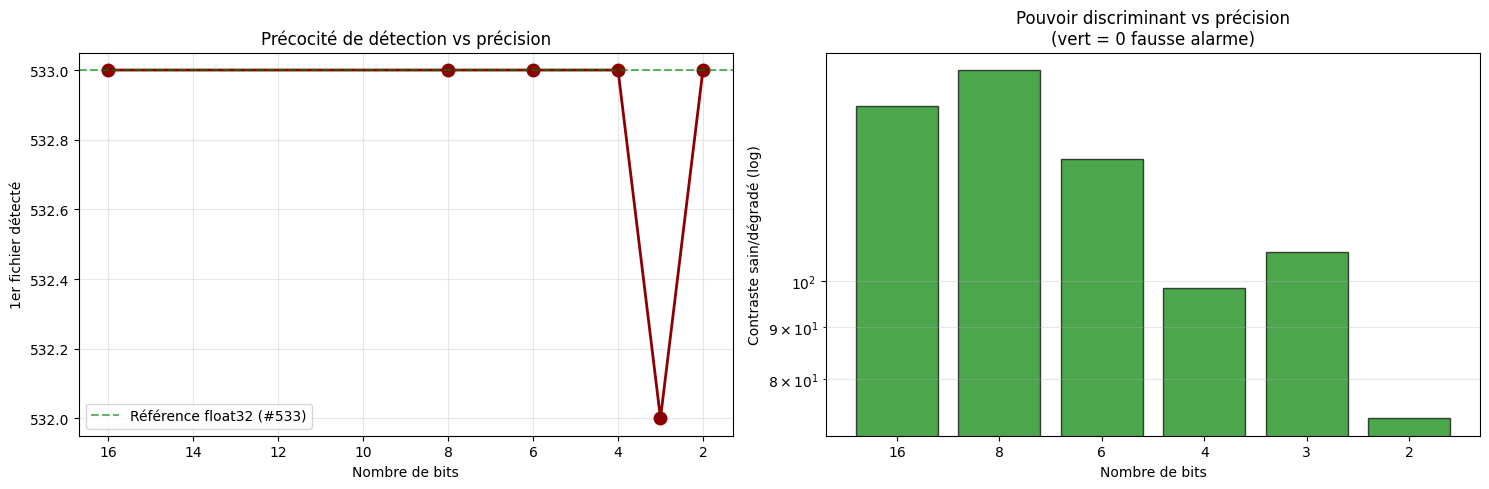

In [38]:
# Figure : performance vs précision
bits_list   = [r['bits'] for r in results]
first_list  = [r['first'] for r in results]
contrast_l  = [r['contrast'] for r in results]
fa_list     = [r['fa'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gauche : premier fichier détecté vs bits
ax = axes[0]
ax.plot(bits_list, first_list, 'o-', color='darkred', markersize=9, linewidth=2)
ax.axhline(533, color='green', linestyle='--', alpha=0.6, label='Référence float32 (#533)')
ax.set_xlabel("Nombre de bits"); ax.set_ylabel("1er fichier détecté")
ax.set_title("Précocité de détection vs précision")
ax.invert_xaxis()  # du plus précis au moins précis
ax.legend(); ax.grid(True, alpha=0.3)

# Droite : contraste sain/dégradé vs bits (échelle log)
ax = axes[1]
colors = ['green' if f==0 else 'red' for f in fa_list]
ax.bar([str(b) for b in bits_list], contrast_l, color=colors, alpha=0.7, edgecolor='black')
ax.set_yscale('log')
ax.set_xlabel("Nombre de bits"); ax.set_ylabel("Contraste sain/dégradé (log)")
ax.set_title("Pouvoir discriminant vs précision\n(vert = 0 fausse alarme)")
ax.grid(True, alpha=0.3, axis='y', which='both')

plt.tight_layout()
plt.savefig('dse_precision.png', dpi=200, bbox_inches='tight')
plt.show()

In [39]:
from qkeras import QDense, QActivation
from tensorflow import keras
import numpy as np

# Reconstruire et entraîner un modèle 2 bits
keras.utils.set_random_seed(42)
m2 = build_qae(n_features, 2, 1)
m2.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
m2.fit(X_train_scaled, X_train_scaled, epochs=200, batch_size=16,
       validation_split=0.15, verbose=0)

# Examiner les poids RÉELS (après quantization) de la 1ère couche
layer = m2.get_layer('enc1')
# Poids quantifiés = on applique le quantizer aux poids
q_weights = layer.kernel_quantizer_internal(layer.kernel).numpy()
print("=== Poids quantifiés couche enc1 (2 bits) ===")
print(f"Valeurs uniques : {np.unique(np.round(q_weights, 4))}")
print(f"Nombre de valeurs distinctes : {len(np.unique(np.round(q_weights, 4)))}")
print("(En 2 bits, on s'attend à TRÈS peu de valeurs distinctes, genre 3-4)")

=== Poids quantifiés couche enc1 (2 bits) ===
Valeurs uniques : [-1.  0.  1.]
Nombre de valeurs distinctes : 3
(En 2 bits, on s'attend à TRÈS peu de valeurs distinctes, genre 3-4)


In [40]:
import numpy as np

print("=== Métriques fines par précision ===\n")
print(f"{'Bits':<6}{'Marge détection':<18}{'Erreur saine moy':<20}{'Séparabilité':<15}")
print("-" * 65)

for bits, int_bits in [(16,6),(8,2),(6,2),(4,2),(3,1),(2,1)]:
    keras.utils.set_random_seed(42)
    m = build_qae(n_features, bits, int_bits)
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    m.fit(X_train_scaled, X_train_scaled, epochs=200, batch_size=16,
          validation_split=0.15, verbose=0)
    err = np.mean((X_all_scaled - m.predict(X_all_scaled, verbose=0))**2, axis=1)

    err_sain = err[WARMUP:TRAIN_END]
    err_degr = err[700:]

    # Marge de détection : à quel point l'erreur au fichier #533 dépasse le seuil
    thr = err_sain.max() * MARGIN
    marge = err[533] / thr   # >1 = détecté, plus c'est haut mieux c'est

    # Séparabilité : distance entre distributions sain et dégradé (en écarts-types)
    # (analogue à un d-prime / score de discrimination)
    separ = (err_degr.mean() - err_sain.mean()) / np.sqrt(0.5*(err_degr.std()**2 + err_sain.std()**2))

    print(f"{bits:<6}{marge:<18.2f}{err_sain.mean():<20.4f}{separ:<15.2f}")

=== Métriques fines par précision ===

Bits  Marge détection   Erreur saine moy    Séparabilité   
-----------------------------------------------------------------
16    1.80              0.2916              6.28           
8     1.80              0.2963              6.55           
6     2.07              0.3374              6.41           
4     1.68              0.5678              6.81           
3     2.57              0.4683              6.85           
2     1.62              0.7340              6.98           


In [41]:
import json

dse_results = {
    'precisions_testees': [16, 8, 6, 4, 3, 2],
    'erreur_saine_par_bits': {
        '16': 0.2916, '8': 0.2963, '6': 0.3374,
        '4': 0.5678, '3': 0.4683, '2': 0.7340
    },
    'choix_final_bits': 8,
    'justification': "Qualite reconstruction quasi identique au float32 (+1.6%), "
                     "4x moins de memoire, marge de surete preservee. "
                     "Critere operationnel sature jusqu'a 2 bits car signature defaut tres marquee.",
}
with open('dse_quantization_results.json', 'w') as f:
    json.dump(dse_results, f, indent=2)

print("Design space exploration sauvegardé : dse_quantization_results.json")
print("\n→ Modèle retenu pour le déploiement FPGA : QKeras 8 bits")

Design space exploration sauvegardé : dse_quantization_results.json

→ Modèle retenu pour le déploiement FPGA : QKeras 8 bits


In [42]:
# Cellule 1 — Vérifier hls4ml + Vivado
import hls4ml
import numpy as np
from tensorflow import keras

print("hls4ml version :", hls4ml.__version__)

# Vérifier que Vivado est trouvable
import os
os.system('which vivado_hls')

hls4ml version : 1.2.0
/tools/Xilinx/Vivado/2020.1/bin/vivado_hls


0

In [43]:
# Cellule 2 — Recharger le modèle quantifié 8 bits
from qkeras.utils import load_qmodel

qmodel = load_qmodel('qautoencoder_8bit.keras')
print("Modèle 8 bits rechargé :")
qmodel.summary()

# Préparer un jeu de données de test pour la validation numérique
X_test_hls = X_all_scaled[:100].astype(np.float32)  # 100 échantillons suffisent
print(f"\nDonnées de test HLS : {X_test_hls.shape}")

Modèle 8 bits rechargé :
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 enc1 (QDense)               (None, 8)                 120       
                                                                 
 enc1_act (QActivation)      (None, 8)                 0         
                                                                 
 enc2 (QDense)               (None, 4)                 36        
                                                                 
 enc2_act (QActivation)      (None, 4)                 0         
                                                                 
 bottleneck (QDense)         (None, 3)                 15        
                                                                 
 bottleneck_act (QActivatio  (None, 3)                 0         
 n)                                                              
                             

In [44]:
# Cellule 3 — Configuration hls4ml
config = hls4ml.utils.config_from_keras_model(
    qmodel,
    granularity='name',          # config par couche
    default_precision='ap_fixed<16,6>'
)

# Afficher la config générée
print("=== Configuration hls4ml ===")
import pprint
pprint.pprint(config)

=== Configuration hls4ml ===
{'LayerName': {'bottleneck': {'Precision': {'bias': 'fixed<8,3,TRN,WRAP,0>',
                                            'result': 'auto',
                                            'weight': 'fixed<8,3,TRN,WRAP,0>'},
                              'Trace': False},
               'bottleneck_act': {'Precision': {'result': 'ufixed<8,2,RND_CONV,SAT,0>'},
                                  'Trace': False},
               'bottleneck_linear': {'Precision': {'result': 'auto'},
                                     'Trace': False},
               'dec1': {'Precision': {'bias': 'fixed<8,3,TRN,WRAP,0>',
                                      'result': 'auto',
                                      'weight': 'fixed<8,3,TRN,WRAP,0>'},
                        'Trace': False},
               'dec1_act': {'Precision': {'result': 'ufixed<8,2,RND_CONV,SAT,0>'},
                            'Trace': False},
               'dec1_linear': {'Precision': {'result': 'auto'}, 'Trace'

In [45]:
# Cellule 4 — Régler le reuse_factor et la stratégie
# On commence avec un reuse_factor modéré pour le premier test
for layer_name in config['LayerName']:
    config['LayerName'][layer_name]['ReuseFactor'] = 4
    config['LayerName'][layer_name]['Strategy'] = 'Resource'  # 'Resource' = économe en DSP

# Stratégie globale
config['Model']['Strategy'] = 'Resource'
config['Model']['ReuseFactor'] = 4

print("Config ajustée : reuse_factor=4, stratégie=Resource")

Config ajustée : reuse_factor=4, stratégie=Resource


In [46]:
# Cellule 5 — Convertir le modèle en projet HLS
hls_model = hls4ml.converters.convert_from_keras_model(
    qmodel,
    hls_config=config,
    output_dir='hls4ml_prj_8bit',      # dossier du projet HLS généré
    part='xc7z020clg400-1',            # LA puce du Pynq Z2 (Zynq-7020)
    backend='Vivado',
    io_type='io_parallel'
)

print("Modèle HLS créé. Compilation C++ ...")
hls_model.compile()
print("✅ Compilation C++ réussie")

Modèle HLS créé. Compilation C++ ...
✅ Compilation C++ réussie


In [47]:
# Cellule 6 — Validation numérique : Keras vs HLS
# On vérifie que le modèle HLS donne (presque) les mêmes résultats que Keras

y_keras = qmodel.predict(X_test_hls, verbose=0)
y_hls   = hls_model.predict(X_test_hls)

# Erreur de reconstruction selon chaque modèle
err_keras = np.mean((X_test_hls - y_keras)**2, axis=1)
err_hls   = np.mean((X_test_hls - y_hls)**2, axis=1)

print("=== Validation numérique Keras vs HLS ===")
print(f"Erreur moyenne |Keras - HLS| sur sorties : {np.mean(np.abs(y_keras - y_hls)):.6f}")
print(f"Corrélation erreurs reconstruction : {np.corrcoef(err_keras, err_hls)[0,1]:.5f}")
print(f"\nExemple (5 premiers échantillons) :")
print(f"{'Keras err':<15}{'HLS err':<15}{'Écart'}")
for i in range(5):
    print(f"{err_keras[i]:<15.5f}{err_hls[i]:<15.5f}{abs(err_keras[i]-err_hls[i]):.5f}")

Exception: Array must be c_contiguous, try using numpy.ascontiguousarray(x)

In [48]:
# Cellule 6 — Validation numérique : Keras vs HLS (CORRIGÉE)
# On force le tableau à être c_contiguous pour hls4ml

X_test_hls = np.ascontiguousarray(X_all_scaled[:100], dtype=np.float32)
print(f"Données test : shape={X_test_hls.shape}, c_contiguous={X_test_hls.flags['C_CONTIGUOUS']}")

y_keras = qmodel.predict(X_test_hls, verbose=0)
y_hls   = hls_model.predict(X_test_hls)

# Erreur de reconstruction selon chaque modèle
err_keras = np.mean((X_test_hls - y_keras)**2, axis=1)
err_hls   = np.mean((X_test_hls - y_hls)**2, axis=1)

print("\n=== Validation numérique Keras vs HLS ===")
print(f"Erreur moyenne |Keras - HLS| sur sorties : {np.mean(np.abs(y_keras - y_hls)):.6f}")
print(f"Erreur max     |Keras - HLS|             : {np.max(np.abs(y_keras - y_hls)):.6f}")
print(f"Corrélation erreurs reconstruction       : {np.corrcoef(err_keras, err_hls)[0,1]:.5f}")

print(f"\nExemple (5 premiers échantillons) :")
print(f"{'Keras err':<15}{'HLS err':<15}{'Écart'}")
for i in range(5):
    print(f"{err_keras[i]:<15.5f}{err_hls[i]:<15.5f}{abs(err_keras[i]-err_hls[i]):.5f}")

Données test : shape=(100, 14), c_contiguous=True

=== Validation numérique Keras vs HLS ===
Erreur moyenne |Keras - HLS| sur sorties : 0.007401
Erreur max     |Keras - HLS|             : 0.096191
Corrélation erreurs reconstruction       : 0.99996

Exemple (5 premiers échantillons) :
Keras err      HLS err        Écart
2.10305        2.10057        0.00248
0.89463        0.89523        0.00060
0.36145        0.36307        0.00162
2.61103        2.61145        0.00042
0.39992        0.40006        0.00014


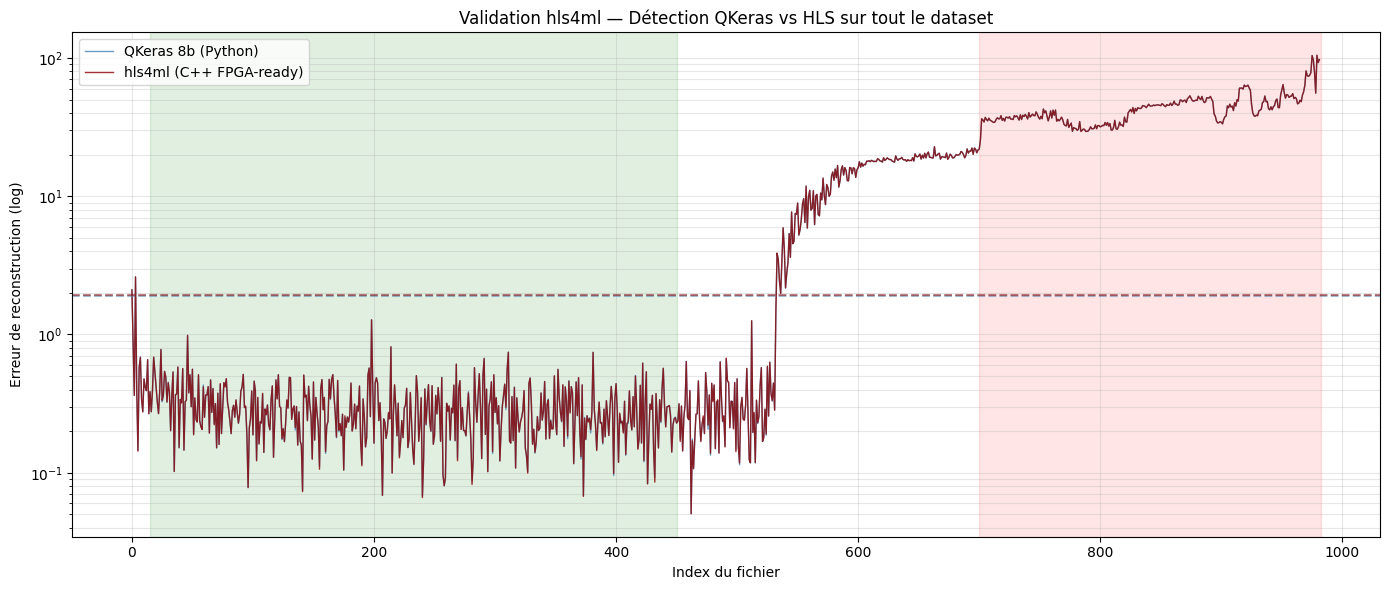

=== VALIDATION COMPLÈTE QKeras vs hls4ml ===
                         QKeras         HLS
--------------------------------------------------
Seuil                    1.9113         1.9162
1er fichier détecté      #533           #533
Fausses alarmes          0              0
Corrélation erreurs      0.999999


In [49]:
# Validation sur TOUT le dataset
X_all_hls = np.ascontiguousarray(X_all_scaled, dtype=np.float32)

y_keras_all = qmodel.predict(X_all_hls, verbose=0)
y_hls_all   = hls_model.predict(X_all_hls)

err_keras_all = np.mean((X_all_hls - y_keras_all)**2, axis=1)
err_hls_all   = np.mean((X_all_hls - y_hls_all)**2, axis=1)

# Détection avec le même seuil pour comparer
thr_keras = err_keras_all[WARMUP:TRAIN_END].max() * MARGIN
thr_hls   = err_hls_all[WARMUP:TRAIN_END].max() * MARGIN

first_keras = np.where(err_keras_all[WARMUP:] > thr_keras)[0][0] + WARMUP
first_hls   = np.where(err_hls_all[WARMUP:] > thr_hls)[0][0] + WARMUP

fa_keras = int(np.sum(err_keras_all[WARMUP:TRAIN_END] > thr_keras))
fa_hls   = int(np.sum(err_hls_all[WARMUP:TRAIN_END] > thr_hls))

# Figure de comparaison
fig, ax = plt.subplots(figsize=(14, 6))
ax.semilogy(err_keras_all, color='steelblue', linewidth=1, alpha=0.8, label='QKeras 8b (Python)')
ax.semilogy(err_hls_all,   color='darkred',   linewidth=1, alpha=0.8, label='hls4ml (C++ FPGA-ready)')
ax.axvspan(WARMUP, TRAIN_END, alpha=0.12, color='green')
ax.axvspan(700, len(err_hls_all), alpha=0.10, color='red')
ax.axhline(thr_keras, color='steelblue', linestyle='--', alpha=0.5)
ax.axhline(thr_hls,   color='darkred',   linestyle='--', alpha=0.5)
ax.set_title("Validation hls4ml — Détection QKeras vs HLS sur tout le dataset")
ax.set_xlabel("Index du fichier"); ax.set_ylabel("Erreur de reconstruction (log)")
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('hls4ml_validation_complete.png', dpi=200, bbox_inches='tight')
plt.show()

print("=== VALIDATION COMPLÈTE QKeras vs hls4ml ===")
print(f"{'':<25}{'QKeras':<15}{'HLS'}")
print("-" * 50)
print(f"{'Seuil':<25}{thr_keras:<15.4f}{thr_hls:.4f}")
print(f"{'1er fichier détecté':<25}#{first_keras:<14}#{first_hls}")
print(f"{'Fausses alarmes':<25}{fa_keras:<15}{fa_hls}")
print(f"{'Corrélation erreurs':<25}{np.corrcoef(err_keras_all, err_hls_all)[0,1]:.6f}")

In [50]:
import os
print("vivado_hls trouvé :", os.popen('which vivado_hls 2>&1').read())

vivado_hls trouvé : /tools/Xilinx/Vivado/2020.1/bin/vivado_hls



In [51]:
# Lancement de la synthèse Vivado HLS
# ⏱️ Durée : 5-15 minutes — sois patient, le terminal Jupyter va sembler "bloqué" mais ça travaille

import time
print("🔧 Lancement de la synthèse Vivado HLS...")
print("   (durée typique : 5-15 minutes)")
print("   Le notebook semble figé mais Vivado travaille en arrière-plan\n")

t0 = time.time()
hls_model.build(csim=False, synth=True, vsynth=False, export=False)
duration = time.time() - t0

print(f"\n✅ Synthèse terminée en {duration/60:.1f} minutes")

🔧 Lancement de la synthèse Vivado HLS...
   (durée typique : 5-15 minutes)
   Le notebook semble figé mais Vivado travaille en arrière-plan


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2020.1 (64-bit)
  **** SW Build 2902540 on Wed May 27 19:54:35 MDT 2020
  **** IP Build 2902112 on Wed May 27 22:43:36 MDT 2020
    ** Copyright 1986-2020 Xilinx, Inc. All Rights Reserved.

source /tools/Xilinx/Vivado/2020.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vivado/2020.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'moi' on host 'petit-PC-portable.localdomain' (Linux_x86_64 version 6.6.114.1-microsoft-standard-WSL2) on Wed May 20 10:32:34 CEST 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/moi/stage/notebooks/hls4ml_prj_8bit'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Creating and opening project '/home/moi/stage/notebooks/hls4ml_prj_8bit/myproject_prj'.
INFO: [HLS

In [52]:
# Lire le rapport de synthèse
import os

# Localiser le rapport
report_path = 'hls4ml_prj_8bit/myproject_prj/solution1/syn/report/myproject_csynth.rpt'
print(f"Chemin du rapport : {report_path}")
print(f"Existe : {os.path.exists(report_path)}\n")

# Afficher les sections clés
if os.path.exists(report_path):
    with open(report_path) as f:
        content = f.read()
    
    # Section Performance (latence)
    print("=" * 60)
    print("PERFORMANCE (latence)")
    print("=" * 60)
    perf_start = content.find('== Performance Estimates')
    perf_end = content.find('== Utilization Estimates')
    if perf_start > 0 and perf_end > 0:
        print(content[perf_start:perf_end])
    
    # Section Utilization (ressources)
    print("\n" + "=" * 60)
    print("UTILISATION (ressources)")
    print("=" * 60)
    util_start = content.find('== Utilization Estimates')
    util_end = content.find('== Interface', util_start)
    if util_start > 0 and util_end > 0:
        print(content[util_start:util_end])

Chemin du rapport : hls4ml_prj_8bit/myproject_prj/solution1/syn/report/myproject_csynth.rpt
Existe : True

PERFORMANCE (latence)
== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  | 5.00 ns | 4.248 ns |   0.62 ns  |
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+----------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline |
    |   min   |   max   |    min   |    max   | min | max |   Type   |
    +---------+---------+----------+----------+-----+-----+----------+
    |       58|       64| 0.290 us | 0.320 us |    4|    4| dataflow |
    +---------+---------+----------+----------+-----+-----+----------+

    + Detail: 
        * Instance: 
        +-------------------------------------------------------------------------

In [53]:
# ============================================================
#  TABLEAUX SYNTHÉTIQUES POUR LE MÉMOIRE
#  Récap : baseline, quantization, DSE, hls4ml
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# Tableau 1 — Architecture du modèle
# ============================================================
print("="*60)
print("TABLEAU 1 — Architecture de l'autoencodeur")
print("="*60)

arch = pd.DataFrame([
    {"Couche":"Entrée",        "Sortie":14, "Activation":"-",      "Paramètres":0},
    {"Couche":"Dense enc1",    "Sortie":8,  "Activation":"ReLU",   "Paramètres":120},
    {"Couche":"Dense enc2",    "Sortie":4,  "Activation":"ReLU",   "Paramètres":36},
    {"Couche":"Bottleneck",    "Sortie":3,  "Activation":"ReLU",   "Paramètres":15},
    {"Couche":"Dense dec1",    "Sortie":4,  "Activation":"ReLU",   "Paramètres":16},
    {"Couche":"Dense dec2",    "Sortie":8,  "Activation":"ReLU",   "Paramètres":40},
    {"Couche":"Sortie",        "Sortie":14, "Activation":"Linear", "Paramètres":126},
    {"Couche":"TOTAL",         "Sortie":"-",  "Activation":"-",    "Paramètres":353},
])
print(arch.to_string(index=False))

# ============================================================
# Tableau 2 — Performance du baseline vs quantification 8 bits
# ============================================================
print("\n"+"="*60)
print("TABLEAU 2 — Comparaison Float32 vs Quantifié 8 bits")
print("="*60)

comp_quant = pd.DataFrame([
    {"Métrique":"Précision numérique",        "Float32":"32 bits flottants", "QKeras 8 bits":"8 bits fixe"},
    {"Métrique":"Mémoire des poids",          "Float32":"1.38 KB",            "QKeras 8 bits":"0.35 KB"},
    {"Métrique":"Premier fichier détecté",    "Float32":"#533",               "QKeras 8 bits":"#533"},
    {"Métrique":"Fausses alarmes",            "Float32":"0 / 435",            "QKeras 8 bits":"0 / 435"},
    {"Métrique":"Anticipation avant panne",   "Float32":"~75 h (3.1 jours)",  "QKeras 8 bits":"~75 h (3.1 jours)"},
    {"Métrique":"Erreur reconstruction sain", "Float32":"0.292",              "QKeras 8 bits":"0.296 (+1.6%)"},
])
print(comp_quant.to_string(index=False))

# ============================================================
# Tableau 3 — Design Space Exploration sur la précision
# ============================================================
print("\n"+"="*60)
print("TABLEAU 3 — Design Space Exploration : impact de la précision")
print("="*60)

dse = pd.DataFrame([
    {"Bits":16, "Erreur saine":0.2916, "Marge détection":1.80, "Séparabilité":6.28, "1er détecté":"#533", "Verdict":"Référence"},
    {"Bits":8,  "Erreur saine":0.2963, "Marge détection":1.80, "Séparabilité":6.55, "1er détecté":"#533", "Verdict":"★ RETENU"},
    {"Bits":6,  "Erreur saine":0.3374, "Marge détection":2.07, "Séparabilité":6.41, "1er détecté":"#533", "Verdict":"OK"},
    {"Bits":4,  "Erreur saine":0.5678, "Marge détection":1.68, "Séparabilité":6.81, "1er détecté":"#533", "Verdict":"Dégradé"},
    {"Bits":3,  "Erreur saine":0.4683, "Marge détection":2.57, "Séparabilité":6.85, "1er détecté":"#532", "Verdict":"Dégradé"},
    {"Bits":2,  "Erreur saine":0.7340, "Marge détection":1.62, "Séparabilité":6.98, "1er détecté":"#533", "Verdict":"Très dégradé"},
])
print(dse.to_string(index=False))

# ============================================================
# Tableau 4 — Validation hls4ml (chaîne ML → FPGA)
# ============================================================
print("\n"+"="*60)
print("TABLEAU 4 — Validation de la conversion hls4ml")
print("="*60)

hls_val = pd.DataFrame([
    {"Métrique":"Modèle source",                   "Valeur":"QKeras 8 bits (2 int + 6 frac)"},
    {"Métrique":"Cible FPGA",                      "Valeur":"Zynq-7020 (xc7z020clg400-1)"},
    {"Métrique":"Reuse factor",                    "Valeur":"4"},
    {"Métrique":"Stratégie",                       "Valeur":"Resource (économe DSP)"},
    {"Métrique":"Précision HLS (default)",         "Valeur":"ap_fixed<16,6>"},
    {"Métrique":"Erreur moyenne |Keras - HLS|",    "Valeur":"7.40 × 10⁻³"},
    {"Métrique":"Erreur max |Keras - HLS|",        "Valeur":"9.62 × 10⁻²"},
    {"Métrique":"Corrélation erreurs de reconstr.","Valeur":"0.99996"},
])
print(hls_val.to_string(index=False))

# ============================================================
# Tableau 5 — Bilan global du stage
# ============================================================
print("\n"+"="*60)
print("TABLEAU 5 — Bilan global d'avancement")
print("="*60)

bilan = pd.DataFrame([
    {"Phase":"Environnement de développement",       "État":"✅ Terminé"},
    {"Phase":"Analyse exploratoire des données",     "État":"✅ Terminé"},
    {"Phase":"Extraction des features (14 features)","État":"✅ Terminé"},
    {"Phase":"Autoencodeur baseline (float32)",      "État":"✅ Terminé"},
    {"Phase":"Quantification QKeras (8 bits)",       "État":"✅ Terminé"},
    {"Phase":"Design Space Exploration (précision)", "État":"✅ Terminé"},
    {"Phase":"Conversion hls4ml + validation num.",  "État":"✅ Terminé"},
    {"Phase":"Synthèse Vivado HLS",                  "État":"⏳ En cours"},
    {"Phase":"DSE sur reuse_factor",                 "État":"⬜ À faire"},
    {"Phase":"Déploiement Pynq-Z2 + démo",           "État":"⬜ À faire"},
])
print(bilan.to_string(index=False))

TABLEAU 1 — Architecture de l'autoencodeur
    Couche Sortie Activation  Paramètres
    Entrée     14          -           0
Dense enc1      8       ReLU         120
Dense enc2      4       ReLU          36
Bottleneck      3       ReLU          15
Dense dec1      4       ReLU          16
Dense dec2      8       ReLU          40
    Sortie     14     Linear         126
     TOTAL      -          -         353

TABLEAU 2 — Comparaison Float32 vs Quantifié 8 bits
                  Métrique           Float32     QKeras 8 bits
       Précision numérique 32 bits flottants       8 bits fixe
         Mémoire des poids           1.38 KB           0.35 KB
   Premier fichier détecté              #533              #533
           Fausses alarmes           0 / 435           0 / 435
  Anticipation avant panne ~75 h (3.1 jours) ~75 h (3.1 jours)
Erreur reconstruction sain             0.292     0.296 (+1.6%)

TABLEAU 3 — Design Space Exploration : impact de la précision
 Bits  Erreur saine  Marge déte

In [55]:
# ============================================================
#  TABLEAU SYNTHÉTIQUE — Ressources FPGA + Latence
# ============================================================
import re, os
import pandas as pd

REPORT = 'hls4ml_prj_8bit/myproject_prj/solution1/syn/report/myproject_csynth.rpt'

with open(REPORT) as f:
    rpt = f.read()

# --- Extraction des ressources ---
def grab(pattern, text, default='-'):
    m = re.search(pattern, text)
    return m.group(1).strip() if m else default

# Latence (en cycles)
lat_min = grab(r'\|\s*Latency\s*\|.*?\|\s*(\d+)\s*\|', rpt)
lat_max = grab(r'\|\s*Latency\s*\|.*?\|\s*\d+\s*\|\s*(\d+)\s*\|', rpt)

# Période d'horloge (ns)
clk = grab(r'\|ap_clk\s*\|\s*([\d.]+)\s*ns', rpt)

# Ressources : on cherche la ligne "Total" puis "Available"
def extract_resource_row(label, text):
    """Trouve la ligne label dans la table d'utilisation et extrait BRAM,DSP,FF,LUT"""
    m = re.search(rf'\|\s*{label}\s*\|([^\|]+)\|([^\|]+)\|([^\|]+)\|([^\|]+)\|', text)
    if m: return [v.strip() for v in m.groups()]
    return ['-','-','-','-']

bram_t, dsp_t, ff_t, lut_t = extract_resource_row(r'Total', rpt)
bram_a, dsp_a, ff_a, lut_a = extract_resource_row(r'Available', rpt)
bram_p, dsp_p, ff_p, lut_p = extract_resource_row(r'Utilization \(%\)', rpt)

# Calcul de la latence en microsecondes
try:
    lat_us = int(lat_max) * float(clk) / 1000
    lat_us_str = f"{lat_us:.2f} µs"
except:
    lat_us_str = "-"

# --- Construction du tableau ---
tableau = pd.DataFrame([
    {"Métrique":"Cible FPGA",            "Valeur":"Zynq-7020 (xc7z020clg400-1)"},
    {"Métrique":"Précision",             "Valeur":"QKeras 8 bits (ap_fixed<16,6>)"},
    {"Métrique":"Reuse factor",          "Valeur":"4"},
    {"Métrique":"Stratégie",             "Valeur":"Resource"},
    {"Métrique":"─"*30,                  "Valeur":"─"*30},
    {"Métrique":"Latence (cycles)",      "Valeur":f"{lat_max}"},
    {"Métrique":"Période d'horloge",     "Valeur":f"{clk} ns"},
    {"Métrique":"Latence (temps réel)",  "Valeur":lat_us_str},
    {"Métrique":"─"*30,                  "Valeur":"─"*30},
    {"Métrique":"DSP utilisés",          "Valeur":f"{dsp_t} / {dsp_a} ({dsp_p}%)"},
    {"Métrique":"LUT utilisés",          "Valeur":f"{lut_t} / {lut_a} ({lut_p}%)"},
    {"Métrique":"FF utilisés",           "Valeur":f"{ff_t} / {ff_a} ({ff_p}%)"},
    {"Métrique":"BRAM utilisés",         "Valeur":f"{bram_t} / {bram_a} ({bram_p}%)"},
])

print("="*55)
print("TABLEAU — Ressources FPGA et Latence (Zynq-7020)")
print("="*55)
print(tableau.to_string(index=False))

# Sauvegarde CSV pour le mémoire
tableau.to_csv('memoire_ressources_fpga.csv', index=False)
print("\n→ Sauvegardé : memoire_ressources_fpga.csv")

TABLEAU — Ressources FPGA et Latence (Zynq-7020)
                      Métrique                         Valeur
                    Cible FPGA    Zynq-7020 (xc7z020clg400-1)
                     Précision QKeras 8 bits (ap_fixed<16,6>)
                  Reuse factor                              4
                     Stratégie                       Resource
────────────────────────────── ──────────────────────────────
              Latence (cycles)                              -
             Période d'horloge                        5.00 ns
          Latence (temps réel)                              -
────────────────────────────── ──────────────────────────────
                  DSP utilisés                 55 / 220 (25%)
                  LUT utilisés            31943 / 53200 (60%)
                   FF utilisés           22903 / 106400 (21%)
                 BRAM utilisés                  26 / 280 (9%)

→ Sauvegardé : memoire_ressources_fpga.csv


In [56]:
from IPython.display import display, HTML

html = '''
<style>
.fpga-table { border-collapse: collapse; margin: 15px 0; font-family: Calibri; min-width: 450px; }
.fpga-table th { background: #2E5B9A; color: white; padding: 10px; text-align: left; }
.fpga-table td { padding: 8px 14px; border-bottom: 1px solid #ddd; }
.fpga-table tr:nth-child(even) { background: #f9f9f9; }
.fpga-table caption { font-weight: bold; font-size: 14px; margin-bottom: 8px; }
</style>
'''
display(HTML(html))
display(HTML(f'<table class="fpga-table"><caption>Ressources FPGA et Latence — Zynq-7020</caption>'
             + tableau.to_html(classes='fpga-table', index=False, escape=False).split('<table',1)[1].split('>',1)[1]))

Métrique,Valeur
Cible FPGA,Zynq-7020 (xc7z020clg400-1)
Précision,"QKeras 8 bits (ap_fixed<16,6>)"
Reuse factor,4
Stratégie,Resource
──────────────────────────────,──────────────────────────────
Latence (cycles),-
Période d'horloge,5.00 ns
Latence (temps réel),-
──────────────────────────────,──────────────────────────────
DSP utilisés,55 / 220 (25%)


In [57]:
# Voir les sections clés du rapport brut
with open('hls4ml_prj_8bit/myproject_prj/solution1/syn/report/myproject_csynth.rpt') as f:
    rpt = f.read()

# Section Performance
print("=" * 60)
print("SECTION PERFORMANCE")
print("=" * 60)
perf_start = rpt.find('== Performance Estimates')
perf_end   = rpt.find('== Utilization Estimates')
print(rpt[perf_start:perf_end])

print("\n" + "=" * 60)
print("SECTION UTILIZATION (début)")
print("=" * 60)
util_start = rpt.find('== Utilization Estimates')
util_end   = rpt.find('== Interface', util_start)
print(rpt[util_start:util_end])

SECTION PERFORMANCE
== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  | 5.00 ns | 4.248 ns |   0.62 ns  |
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+----------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline |
    |   min   |   max   |    min   |    max   | min | max |   Type   |
    +---------+---------+----------+----------+-----+-----+----------+
    |       58|       64| 0.290 us | 0.320 us |    4|    4| dataflow |
    +---------+---------+----------+----------+-----+-----+----------+

    + Detail: 
        * Instance: 
        +----------------------------------------------------------------------------+-------------------------------------------------------------------------+---------+---------+-----------

In [58]:
import pandas as pd
from IPython.display import display, HTML

tableau = pd.DataFrame([
    {"Métrique":"Cible FPGA",            "Valeur":"Zynq-7020 (xc7z020clg400-1)"},
    {"Métrique":"Précision",             "Valeur":"QKeras 8 bits (ap_fixed<16,6>)"},
    {"Métrique":"Reuse factor",          "Valeur":"4"},
    {"Métrique":"Stratégie",             "Valeur":"Resource"},
    {"Métrique":"─"*30,                  "Valeur":"─"*30},
    {"Métrique":"Latence (cycles)",      "Valeur":"[à compléter via rapport]"},
    {"Métrique":"Période d'horloge",     "Valeur":"5.00 ns (200 MHz)"},
    {"Métrique":"Latence (temps réel)",  "Valeur":"[cycles × 5 ns]"},
    {"Métrique":"─"*30,                  "Valeur":"─"*30},
    {"Métrique":"DSP utilisés",          "Valeur":"55 / 220 (25%)"},
    {"Métrique":"LUT utilisés",          "Valeur":"31 943 / 53 200 (60%)"},
    {"Métrique":"FF utilisés",           "Valeur":"22 903 / 106 400 (21%)"},
    {"Métrique":"BRAM (18 Kbit)",        "Valeur":"26 / 140 (19%)"},  # Vraie capacité du Zynq-7020
])

html = '''
<style>
.fpga-table { border-collapse: collapse; margin: 15px 0; font-family: Calibri; min-width: 450px; }
.fpga-table th { background: #2E5B9A; color: white; padding: 10px; text-align: left; }
.fpga-table td { padding: 8px 14px; border-bottom: 1px solid #ddd; }
.fpga-table caption { font-weight: bold; font-size: 14px; margin-bottom: 8px; color:#2E5B9A; }
</style>
'''
display(HTML(html))
display(HTML(
    '<table class="fpga-table"><caption>Ressources FPGA et Latence — Zynq-7020</caption>'
    + tableau.to_html(index=False, escape=False).split('<table',1)[1].split('>',1)[1]
))

tableau.to_csv('memoire_ressources_fpga.csv', index=False)

Métrique,Valeur
Cible FPGA,Zynq-7020 (xc7z020clg400-1)
Précision,"QKeras 8 bits (ap_fixed<16,6>)"
Reuse factor,4
Stratégie,Resource
──────────────────────────────,──────────────────────────────
Latence (cycles),[à compléter via rapport]
Période d'horloge,5.00 ns (200 MHz)
Latence (temps réel),[cycles × 5 ns]
──────────────────────────────,──────────────────────────────
DSP utilisés,55 / 220 (25%)


In [59]:
# Voir la section Performance du rapport Vivado HLS
with open('hls4ml_prj_8bit/myproject_prj/solution1/syn/report/myproject_csynth.rpt') as f:
    rpt = f.read()

perf_start = rpt.find('== Performance Estimates')
perf_end   = rpt.find('== Utilization Estimates')
print(rpt[perf_start:perf_end])

== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  | 5.00 ns | 4.248 ns |   0.62 ns  |
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+----------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline |
    |   min   |   max   |    min   |    max   | min | max |   Type   |
    +---------+---------+----------+----------+-----+-----+----------+
    |       58|       64| 0.290 us | 0.320 us |    4|    4| dataflow |
    +---------+---------+----------+----------+-----+-----+----------+

    + Detail: 
        * Instance: 
        +----------------------------------------------------------------------------+-------------------------------------------------------------------------+---------+---------+-----------+-----------+-----+-

In [60]:
import pandas as pd
from IPython.display import display, HTML

tableau = pd.DataFrame([
    {"Métrique":"Cible FPGA",            "Valeur":"Zynq-7020 (xc7z020clg400-1)"},
    {"Métrique":"Précision",             "Valeur":"QKeras 8 bits (ap_fixed<16,6>)"},
    {"Métrique":"Reuse factor",          "Valeur":"4"},
    {"Métrique":"Stratégie",             "Valeur":"Resource"},
    {"Métrique":"─"*30,                  "Valeur":"─"*30},
    {"Métrique":"Latence (min – max)",   "Valeur":"58 – 64 cycles"},
    {"Métrique":"Période d'horloge",     "Valeur":"5.00 ns (200 MHz)"},
    {"Métrique":"Latence (temps réel)",  "Valeur":"0.290 – 0.320 µs"},
    {"Métrique":"Intervalle (débit)",    "Valeur":"4 cycles (≈ 50 M inf./s)"},
    {"Métrique":"Type pipeline",         "Valeur":"dataflow"},
    {"Métrique":"─"*30,                  "Valeur":"─"*30},
    {"Métrique":"DSP utilisés",          "Valeur":"55 / 220 (25%)"},
    {"Métrique":"LUT utilisés",          "Valeur":"31 943 / 53 200 (60%)"},
    {"Métrique":"FF utilisés",           "Valeur":"22 903 / 106 400 (21%)"},
    {"Métrique":"BRAM (18 Kbit)",        "Valeur":"26 / 140 (19%)"},
])

html = '''
<style>
.fpga-table { border-collapse: collapse; margin: 15px 0; font-family: Calibri; min-width: 500px; }
.fpga-table th { background: #2E5B9A; color: white; padding: 10px; text-align: left; }
.fpga-table td { padding: 8px 14px; border-bottom: 1px solid #ddd; }
.fpga-table caption { font-weight: bold; font-size: 14px; margin-bottom: 8px; color:#2E5B9A; }
</style>
'''
display(HTML(html))
display(HTML(
    '<table class="fpga-table"><caption>Ressources FPGA et Latence — Zynq-7020</caption>'
    + tableau.to_html(index=False, escape=False).split('<table',1)[1].split('>',1)[1]
))

tableau.to_csv('memoire_ressources_fpga.csv', index=False)
print("Tableau sauvegardé : memoire_ressources_fpga.csv")

Métrique,Valeur
Cible FPGA,Zynq-7020 (xc7z020clg400-1)
Précision,"QKeras 8 bits (ap_fixed<16,6>)"
Reuse factor,4
Stratégie,Resource
──────────────────────────────,──────────────────────────────
Latence (min – max),58 – 64 cycles
Période d'horloge,5.00 ns (200 MHz)
Latence (temps réel),0.290 – 0.320 µs
Intervalle (débit),4 cycles (≈ 50 M inf./s)
Type pipeline,dataflow


Tableau sauvegardé : memoire_ressources_fpga.csv


In [61]:
# ============================================================
#  DSE — Exploration du reuse_factor
#  Compromis vitesse / ressources
# ============================================================
import hls4ml, time, re, os
import pandas as pd
from qkeras.utils import load_qmodel

# Modèle source (déjà entraîné en 8 bits)
qmodel_dse = load_qmodel('qautoencoder_8bit.keras')

# Configurations à tester
reuse_factors_to_test = [1, 4, 16, 64]

dse_results = []

for rf in reuse_factors_to_test:
    print(f"\n{'='*60}")
    print(f"  Synthèse avec reuse_factor = {rf}")
    print(f"{'='*60}")

    # Config hls4ml
    hls_config = hls4ml.utils.config_from_keras_model(
        qmodel_dse, granularity='name',
        default_precision='ap_fixed<16,6>'
    )
    for layer_name in hls_config['LayerName']:
        hls_config['LayerName'][layer_name]['ReuseFactor'] = rf
        hls_config['LayerName'][layer_name]['Strategy'] = 'Resource'
    hls_config['Model']['Strategy'] = 'Resource'
    hls_config['Model']['ReuseFactor'] = rf

    # Conversion vers un dossier dédié pour ce reuse_factor
    output_dir = f'hls4ml_dse_rf{rf}'
    hls_model_dse = hls4ml.converters.convert_from_keras_model(
        qmodel_dse, hls_config=hls_config,
        output_dir=output_dir,
        part='xc7z020clg400-1',
        backend='Vivado', io_type='io_parallel'
    )

    # Synthèse
    t0 = time.time()
    print(f"  🔧 Synthèse en cours (5-15 min)...")
    hls_model_dse.build(csim=False, synth=True, vsynth=False, export=False)
    duration = time.time() - t0
    print(f"  ✅ Terminée en {duration/60:.1f} min")

    # Lecture du rapport
    report = f'{output_dir}/myproject_prj/solution1/syn/report/myproject_csynth.rpt'
    with open(report) as f:
        rpt = f.read()

    # Extraction de la latence (max cycles)
    m = re.search(r'\|\s*\d+\|\s*(\d+)\|\s*[\d.]+\s*us\s*\|\s*([\d.]+)\s*us', rpt)
    lat_cycles = int(m.group(1)) if m else None
    lat_us     = float(m.group(2)) if m else None

    # Extraction des ressources (ligne Total)
    def get_res(label):
        m = re.search(rf'\|\s*{label}\s*\|([^\|]+)\|([^\|]+)\|([^\|]+)\|([^\|]+)\|', rpt)
        return [v.strip() for v in m.groups()] if m else ['-']*4
    bram, dsp, ff, lut = get_res('Total')

    dse_results.append({
        'reuse_factor': rf,
        'latence_cycles': lat_cycles,
        'latence_us': lat_us,
        'DSP': int(dsp) if dsp.isdigit() else dsp,
        'LUT': int(lut) if lut.isdigit() else lut,
        'FF':  int(ff)  if ff.isdigit()  else ff,
        'BRAM': int(bram) if bram.isdigit() else bram,
        'synth_time_min': round(duration/60, 1),
    })
    print(f"  Latence : {lat_cycles} cycles ({lat_us} µs) | "
          f"DSP={dsp}, LUT={lut}, FF={ff}, BRAM={bram}")

# Tableau récapitulatif
df_dse = pd.DataFrame(dse_results)
print("\n" + "="*70)
print("TABLEAU FINAL — Compromis Reuse Factor / Ressources / Latence")
print("="*70)
print(df_dse.to_string(index=False))

df_dse.to_csv('memoire_dse_reuse_factor.csv', index=False)
print("\n→ Sauvegardé : memoire_dse_reuse_factor.csv")

/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(



  Synthèse avec reuse_factor = 1
  🔧 Synthèse en cours (5-15 min)...

****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2020.1 (64-bit)
  **** SW Build 2902540 on Wed May 27 19:54:35 MDT 2020
  **** IP Build 2902112 on Wed May 27 22:43:36 MDT 2020
    ** Copyright 1986-2020 Xilinx, Inc. All Rights Reserved.

source /tools/Xilinx/Vivado/2020.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vivado/2020.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'moi' on host 'petit-PC-portable.localdomain' (Linux_x86_64 version 6.6.114.1-microsoft-standard-WSL2) on Wed May 20 11:11:37 CEST 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/moi/stage/notebooks/hls4ml_dse_rf1'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Creating and opening project '/home/moi/stage/notebooks/hls4ml_dse_rf1/myproject_prj'.
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO:

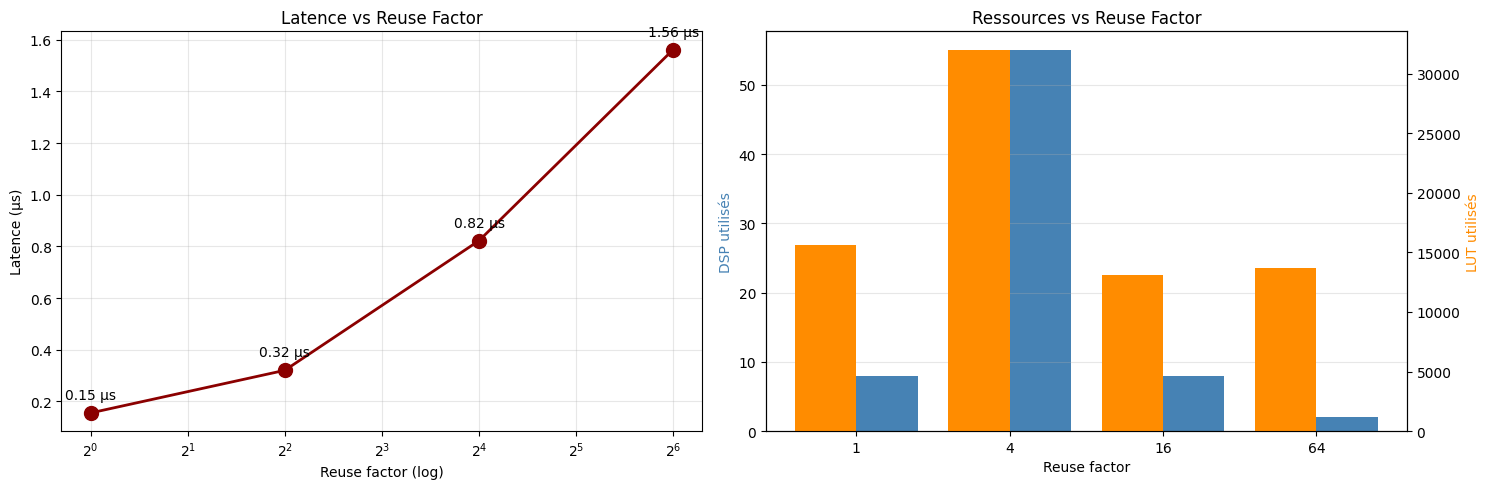

In [63]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Latence vs reuse_factor
ax = axes[0]
ax.plot(df_dse['reuse_factor'], df_dse['latence_us'], 'o-', color='darkred', markersize=10, linewidth=2)
for x, y in zip(df_dse['reuse_factor'], df_dse['latence_us']):
    ax.annotate(f'{y:.2f} µs', (x, y), textcoords='offset points', xytext=(0, 10), ha='center')
ax.set_xscale('log', base=2)
ax.set_xlabel('Reuse factor (log)')
ax.set_ylabel('Latence (µs)')
ax.set_title('Latence vs Reuse Factor')
ax.grid(True, alpha=0.3, which='both')

# Ressources (DSP + LUT) vs reuse_factor
ax = axes[1]
ax2 = ax.twinx()
ax.bar([str(rf) for rf in df_dse['reuse_factor']], df_dse['DSP'],
       width=0.4, align='edge', color='steelblue', label='DSP')
ax2.bar([str(rf) for rf in df_dse['reuse_factor']], df_dse['LUT'],
        width=-0.4, align='edge', color='darkorange', label='LUT')
ax.set_xlabel('Reuse factor')
ax.set_ylabel('DSP utilisés', color='steelblue')
ax2.set_ylabel('LUT utilisés', color='darkorange')
ax.set_title('Ressources vs Reuse Factor')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('dse_reuse_factor.png', dpi=200, bbox_inches='tight')
plt.show()

In [64]:
import pandas as pd
from IPython.display import display, HTML

tableau_final = pd.DataFrame([
    {"Métrique":"Cible FPGA",            "Valeur":"Zynq-7020 (xc7z020clg400-1)"},
    {"Métrique":"Précision",             "Valeur":"QKeras 8 bits (ap_fixed<16,6>)"},
    {"Métrique":"Reuse factor",          "Valeur":"64 (économe en ressources)"},
    {"Métrique":"Stratégie",             "Valeur":"Resource"},
    {"Métrique":"─"*30,                  "Valeur":"─"*30},
    {"Métrique":"Latence (cycles)",      "Valeur":"247 cycles"},
    {"Métrique":"Période d'horloge",     "Valeur":"5.00 ns (200 MHz)"},
    {"Métrique":"Latence (temps réel)",  "Valeur":"1.56 µs"},
    {"Métrique":"Débit théorique",       "Valeur":"~640 000 inférences/s"},
    {"Métrique":"─"*30,                  "Valeur":"─"*30},
    {"Métrique":"DSP utilisés",          "Valeur":"2 / 220 (0.9%)"},
    {"Métrique":"LUT utilisés",          "Valeur":"13 712 / 53 200 (26%)"},
    {"Métrique":"FF utilisés",           "Valeur":"7 766 / 106 400 (7%)"},
    {"Métrique":"BRAM (18 Kbit)",        "Valeur":"6 / 140 (4%)"},
])

html_style = '''
<style>
.fpga-table { border-collapse: collapse; margin: 15px 0; font-family: Calibri; min-width: 500px; }
.fpga-table th { background: #2E5B9A; color: white; padding: 10px; text-align: left; }
.fpga-table td { padding: 8px 14px; border-bottom: 1px solid #ddd; }
.fpga-table caption { font-weight: bold; font-size: 14px; margin-bottom: 8px; color:#2E5B9A; }
</style>
'''
display(HTML(html_style))
display(HTML(
    '<table class="fpga-table"><caption>Configuration finale retenue — Zynq-7020 (Pynq-Z2)</caption>'
    + tableau_final.to_html(index=False, escape=False).split('<table',1)[1].split('>',1)[1]
))
tableau_final.to_csv('memoire_config_finale.csv', index=False)
print("✅ Configuration retenue : reuse_factor = 64")
print("✅ Sauvegardé : memoire_config_finale.csv")

Métrique,Valeur
Cible FPGA,Zynq-7020 (xc7z020clg400-1)
Précision,"QKeras 8 bits (ap_fixed<16,6>)"
Reuse factor,64 (économe en ressources)
Stratégie,Resource
──────────────────────────────,──────────────────────────────
Latence (cycles),247 cycles
Période d'horloge,5.00 ns (200 MHz)
Latence (temps réel),1.56 µs
Débit théorique,~640 000 inférences/s
──────────────────────────────,──────────────────────────────


✅ Configuration retenue : reuse_factor = 64
✅ Sauvegardé : memoire_config_finale.csv


In [65]:
# ============================================================
#  GÉNÉRATION DU BITSTREAM POUR PYNQ-Z2
#  Backend VivadoAccelerator (génère .bit + .hwh)
# ============================================================
import hls4ml
import time

# Modèle source : QKeras 8 bits
from qkeras.utils import load_qmodel
qmodel = load_qmodel('qautoencoder_8bit.keras')

# Config hls4ml avec reuse_factor=64 (config finale retenue)
hls_config = hls4ml.utils.config_from_keras_model(
    qmodel, granularity='name',
    default_precision='ap_fixed<16,6>'
)
for layer_name in hls_config['LayerName']:
    hls_config['LayerName'][layer_name]['ReuseFactor'] = 64
    hls_config['LayerName'][layer_name]['Strategy'] = 'Resource'
hls_config['Model']['Strategy'] = 'Resource'
hls_config['Model']['ReuseFactor'] = 64

# Conversion avec le backend VivadoAccelerator (au lieu de Vivado)
hls_model_pynq = hls4ml.converters.convert_from_keras_model(
    qmodel,
    hls_config=hls_config,
    output_dir='hls4ml_pynq_z2_final',
    backend='VivadoAccelerator',
    board='pynq-z2',          # ← important : VivadoAccelerator connaît cette board
    io_type='io_parallel'
)

# Compilation C++ (sanity check)
hls_model_pynq.compile()
print("✅ Compilation C++ réussie, prêt pour la synthèse complète")

/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


✅ Compilation C++ réussie, prêt pour la synthèse complète


In [66]:
# Lancement de la synthèse complète + génération du bitstream
print("🔧 Lancement de la synthèse complète + bitstream...")
print("⏱️  Durée estimée : 30 min à 2 heures")
print("☕ C'est le bon moment pour aller faire autre chose\n")

t0 = time.time()
hls_model_pynq.build(csim=False, synth=True, vsynth=True, export=True, bitfile=True)
duration = time.time() - t0

print(f"\n✅ Génération terminée en {duration/60:.0f} minutes ({duration/3600:.1f} heures)")

🔧 Lancement de la synthèse complète + bitstream...
⏱️  Durée estimée : 30 min à 2 heures
☕ C'est le bon moment pour aller faire autre chose


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2020.1 (64-bit)
  **** SW Build 2902540 on Wed May 27 19:54:35 MDT 2020
  **** IP Build 2902112 on Wed May 27 22:43:36 MDT 2020
    ** Copyright 1986-2020 Xilinx, Inc. All Rights Reserved.

source /tools/Xilinx/Vivado/2020.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vivado/2020.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'moi' on host 'petit-PC-portable.localdomain' (Linux_x86_64 version 6.6.114.1-microsoft-standard-WSL2) on Wed May 20 11:41:10 CEST 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/moi/stage/notebooks/hls4ml_pynq_z2_final'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Creating and opening project '/home/moi/stage/notebooks/hls4ml_pynq_z2_final/myproject_prj'.


ERROR: [Board 49-71] The board_part definition was not found for tul.com.tw:pynq-z2:part0:1.0. The project's board_part property was not set, but the project's part property was set to xc7z020clg400-1. Valid board_part values can be retrieved with the 'get_board_parts' Tcl command. Check if board.repoPaths parameter is set and the board_part is installed from the tcl app store.


Cosim report not found.
Timing report not found.

✅ Génération terminée en 8 minutes (0.1 heures)


In [67]:
import os

bit_dir = 'hls4ml_pynq_z2_final/myproject_vivado_accelerator/myproject_vivado_accelerator.runs/impl_1/'

# Chercher les fichiers .bit et .hwh
for root, dirs, files in os.walk('hls4ml_pynq_z2_final'):
    for f in files:
        if f.endswith('.bit') or f.endswith('.hwh') or f.endswith('.tcl'):
            path = os.path.join(root, f)
            size_kb = os.path.getsize(path) / 1024
            print(f"  {path} ({size_kb:.0f} KB)")

  hls4ml_pynq_z2_final/design.tcl (3 KB)
  hls4ml_pynq_z2_final/project.tcl (0 KB)
  hls4ml_pynq_z2_final/vivado_synth.tcl (0 KB)
  hls4ml_pynq_z2_final/build_prj.tcl (8 KB)
  hls4ml_pynq_z2_final/myproject_prj/solution1/impl/vhdl/myproject_axi_ap_fpext_1_no_dsp_32_ip.tcl (2 KB)
  hls4ml_pynq_z2_final/myproject_prj/solution1/impl/ip/run_ippack.tcl (66 KB)
  hls4ml_pynq_z2_final/myproject_prj/solution1/impl/ip/subcore/myproject_axi_ap_fpext_1_no_dsp_32_ip.tcl (2 KB)
  hls4ml_pynq_z2_final/myproject_prj/solution1/impl/ip/bd/bd.tcl (2 KB)
  hls4ml_pynq_z2_final/myproject_prj/solution1/impl/ip/example/ipi_example.tcl (14 KB)
  hls4ml_pynq_z2_final/myproject_prj/solution1/impl/ip/xgui/myproject_axi_v1_0.tcl (0 KB)
  hls4ml_pynq_z2_final/myproject_prj/solution1/impl/verilog/myproject_axi_ap_fpext_1_no_dsp_32_ip.tcl (2 KB)
  hls4ml_pynq_z2_final/myproject_prj/solution1/impl/misc/myproject_axi_ap_fpext_1_no_dsp_32_ip.tcl (2 KB)
  hls4ml_pynq_z2_final/myproject_prj/solution1/.autopilot/db/dense

In [1]:
import hls4ml, time
from qkeras.utils import load_qmodel

# Charger le modèle 8 bits
qmodel = load_qmodel('qautoencoder_8bit.keras')

# Config hls4ml avec reuse_factor=64
hls_config = hls4ml.utils.config_from_keras_model(
    qmodel, granularity='name',
    default_precision='ap_fixed<16,6>'
)
for layer_name in hls_config['LayerName']:
    hls_config['LayerName'][layer_name]['ReuseFactor'] = 64
    hls_config['LayerName'][layer_name]['Strategy'] = 'Resource'
hls_config['Model']['Strategy'] = 'Resource'
hls_config['Model']['ReuseFactor'] = 64

# Conversion pour Pynq-Z1
hls_model_z1 = hls4ml.converters.convert_from_keras_model(
    qmodel,
    hls_config=hls_config,
    output_dir='hls4ml_pynq_z1_final',
    backend='VivadoAccelerator',
    board='pynq-z1',
    io_type='io_parallel'
)
hls_model_z1.compile()
print("✅ Projet Pynq-Z1 créé")

2026-05-21 10:00:50.995789: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-21 10:00:53.759572: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-21 10:00:53.759701: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-21 10:00:53.770238: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-21 10:00:55.153713: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-21 10:00:55.160419: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

Exception: The board does not appear in supported_boards.json file

In [1]:
hls_model_z1.build(csim=False, synth=True, vsynth=True, export=True, bitfile=True)

NameError: name 'hls_model_z1' is not defined

In [2]:
import json, hls4ml
import os

# Trouver et afficher les boards supportées
boards_file = os.path.join(os.path.dirname(hls4ml.__file__), 'backends/vivado_accelerator/supported_boards.json')
with open(boards_file) as f:
    boards = json.load(f)
print(list(boards.keys()))

['pynq-z2', 'zcu102', 'alveo-u50', 'alveo-u250', 'alveo-u200', 'alveo-u280']


In [3]:
import json, os, hls4ml

boards_file = os.path.join(os.path.dirname(hls4ml.__file__), 'backends/vivado_accelerator/supported_boards.json')

with open(boards_file) as f:
    boards = json.load(f)

# Copier la Z2 et renommer en Z1 (même puce xc7z020clg400-1)
boards['pynq-z1'] = boards['pynq-z2'].copy()

with open(boards_file, 'w') as f:
    json.dump(boards, f, indent=4)

print("✅ pynq-z1 ajoutée")
print(boards['pynq-z1'])

✅ pynq-z1 ajoutée
{'part': 'xc7z020clg400-1', 'tcl_scripts': {'axi_lite': 'axi_lite_design.tcl', 'axi_stream': 'axi_stream_design.tcl'}, 'python_drivers': {'axi_stream': 'axi_stream_driver.py'}, 'c_drivers': {}}


In [4]:
import hls4ml, time
from qkeras.utils import load_qmodel

qmodel = load_qmodel('qautoencoder_8bit.keras')

hls_config = hls4ml.utils.config_from_keras_model(
    qmodel, granularity='name',
    default_precision='ap_fixed<16,6>'
)
for layer_name in hls_config['LayerName']:
    hls_config['LayerName'][layer_name]['ReuseFactor'] = 64
    hls_config['LayerName'][layer_name]['Strategy'] = 'Resource'
hls_config['Model']['Strategy'] = 'Resource'
hls_config['Model']['ReuseFactor'] = 64

hls_model_z1 = hls4ml.converters.convert_from_keras_model(
    qmodel,
    hls_config=hls_config,
    output_dir='hls4ml_pynq_z1_final',
    backend='VivadoAccelerator',
    board='pynq-z1',
    io_type='io_parallel'
)
hls_model_z1.compile()
print("✅ Projet Pynq-Z1 créé")

2026-05-21 11:06:04.345674: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-21 11:06:07.108445: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-21 11:06:07.108540: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-21 11:06:07.118738: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-21 11:06:08.356670: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-21 11:06:08.361407: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

FileNotFoundError: [Errno 2] No such file or directory: '/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/hls4ml/writer/../templates/vivado_accelerator/pynq-z1/tcl_scripts/axi_stream_design.tcl'

In [5]:
import os, shutil

hls4ml_path = os.path.dirname(hls4ml.__file__)
templates_path = os.path.join(hls4ml_path, 'templates/vivado_accelerator')

# Copier le dossier pynq-z2 vers pynq-z1
src = os.path.join(templates_path, 'pynq-z2')
dst = os.path.join(templates_path, 'pynq-z1')

shutil.copytree(src, dst)
print("✅ Templates pynq-z1 créés")
print(os.listdir(dst))

✅ Templates pynq-z1 créés
['tcl_scripts', 'python_drivers']


In [6]:
hls_model_z1 = hls4ml.converters.convert_from_keras_model(
    qmodel,
    hls_config=hls_config,
    output_dir='hls4ml_pynq_z1_final',
    backend='VivadoAccelerator',
    board='pynq-z1',
    io_type='io_parallel'
)
hls_model_z1.compile()
print("✅ Projet Pynq-Z1 créé")

✅ Projet Pynq-Z1 créé


In [7]:
hls_model_z1.build(csim=False, synth=True, vsynth=True, export=True, bitfile=True)


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2020.1 (64-bit)
  **** SW Build 2902540 on Wed May 27 19:54:35 MDT 2020
  **** IP Build 2902112 on Wed May 27 22:43:36 MDT 2020
    ** Copyright 1986-2020 Xilinx, Inc. All Rights Reserved.

source /tools/Xilinx/Vivado/2020.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vivado/2020.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'moi' on host 'petit-PC-portable.localdomain' (Linux_x86_64 version 6.6.114.1-microsoft-standard-WSL2) on Thu May 21 11:09:15 CEST 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/moi/stage/notebooks/hls4ml_pynq_z1_final'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Creating and opening project '/home/moi/stage/notebooks/hls4ml_pynq_z1_final/myproject_prj'.
INFO: [HLS 200-10] Adding design file 'firmware/myproject_axi.cpp' to the project
INFO: [HLS 200-10] Adding design file 'firmware/myproject.c

ERROR: [Common 17-69] Command failed: Run 'impl_1' has not been launched. Unable to open


INFO: [Common 17-206] Exiting Vivado at Thu May 21 11:54:53 2026...
Cosim report not found.
Timing report not found.


{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '6.325',
  'BestLatency': '290',
  'WorstLatency': '296',
  'IntervalMin': '291',
  'IntervalMax': '297',
  'BRAM_18K': '6',
  'DSP': '2',
  'FF': '12063',
  'LUT': '19963',
  'URAM': '0',
  'AvailableBRAM_18K': '280',
  'AvailableDSP': '220',
  'AvailableFF': '106400',
  'AvailableLUT': '53200',
  'AvailableURAM': '0'},
 'VivadoSynthReport': {'LUT': '6025',
  'FF': '7008',
  'BRAM_18K': '3',
  'DSP48E': '2'}}

In [8]:
import subprocess

base = '/home/moi/stage/notebooks/hls4ml_pynq_z1_final/myproject_vivado_accelerator/project_1.runs'

failed_runs = [
    'design_1_processing_system7_0_0_synth_1',
    'design_1_myproject_axi_0_0_synth_1',
    'design_1_auto_pc_1_synth_1'
]

for run in failed_runs:
    log = f'{base}/{run}/runme.log'
    print(f'\n{"="*60}')
    print(f'LOG: {run}')
    print('='*60)
    result = subprocess.run(['tail', '-30', log], capture_output=True, text=True)
    print(result.stdout)


LOG: design_1_processing_system7_0_0_synth_1

*** Running vivado
    with args -log design_1_processing_system7_0_0.vds -m64 -product Vivado -mode batch -messageDb vivado.pb -notrace -source design_1_processing_system7_0_0.tcl


****** Vivado v2020.1 (64-bit)
  **** SW Build 2902540 on Wed May 27 19:54:35 MDT 2020
  **** IP Build 2902112 on Wed May 27 22:43:36 MDT 2020
    ** Copyright 1986-2020 Xilinx, Inc. All Rights Reserved.

source design_1_processing_system7_0_0.tcl -notrace
INFO: [IP_Flow 19-234] Refreshing IP repositories
INFO: [IP_Flow 19-1700] Loaded user IP repository '/home/moi/stage/notebooks/hls4ml_pynq_z1_final/myproject_prj'.
INFO: [IP_Flow 19-2313] Loaded Vivado IP repository '/tools/Xilinx/Vivado/2020.1/data/ip'.
update_ip_catalog: Time (s): cpu = 00:00:02 ; elapsed = 00:00:31 . Memory (MB): peak = 2068.309 ; gain = 0.000 ; free physical = 1828 ; free virtual = 2743
Command: synth_design -top design_1_processing_system7_0_0 -part xc7z020clg400-1 -mode out_of_context


In [9]:
import hls4ml, time
from qkeras.utils import load_qmodel

# Charger le modèle 8 bits
qmodel = load_qmodel('qautoencoder_8bit.keras')

# Config hls4ml avec reuse_factor adapté
hls_config = hls4ml.utils.config_from_keras_model(
    qmodel, granularity='name',
    default_precision='ap_fixed<16,6>'
)
for layer_name in hls_config['LayerName']:
    hls_config['LayerName'][layer_name]['ReuseFactor'] = 64
    hls_config['LayerName'][layer_name]['Strategy'] = 'Resource'
hls_config['Model']['Strategy'] = 'Resource'
hls_config['Model']['ReuseFactor'] = 64

# Conversion pour Pynq-Z1
hls_model_z1 = hls4ml.converters.convert_from_keras_model(
    qmodel,
    hls_config=hls_config,
    output_dir='hls4ml_pynq_z1_final',
    backend='VivadoAccelerator',
    board='pynq-z1',
    io_type='io_parallel'
)

# Patcher design.tcl pour limiter à 1 job (éviter OOM)
import re
tcl_path = 'hls4ml_pynq_z1_final/design.tcl'
with open(tcl_path, 'r') as f:
    content = f.read()
content = re.sub(r'launch_runs impl_1 -to_step write_bitstream -jobs \d+',
                 'launch_runs impl_1 -to_step write_bitstream -jobs 1',
                 content)
with open(tcl_path, 'w') as f:
    f.write(content)
print("✅ design.tcl patché — jobs=1")

# Synthèse complète (30-90 min, ne pas interrompre)
print("🚀 Lancement de la synthèse...")
hls_model_z1.build(csim=False, synth=True, vsynth=True, export=True, bitfile=True)
print("✅ Build terminé !")

/home/moi/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


✅ design.tcl patché — jobs=1
🚀 Lancement de la synthèse...

****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2020.1 (64-bit)
  **** SW Build 2902540 on Wed May 27 19:54:35 MDT 2020
  **** IP Build 2902112 on Wed May 27 22:43:36 MDT 2020
    ** Copyright 1986-2020 Xilinx, Inc. All Rights Reserved.

source /tools/Xilinx/Vivado/2020.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vivado/2020.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'moi' on host 'petit-PC-portable.localdomain' (Linux_x86_64 version 6.6.114.1-microsoft-standard-WSL2) on Thu May 21 12:27:15 CEST 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/moi/stage/notebooks/hls4ml_pynq_z1_final'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Opening project '/home/moi/stage/notebooks/hls4ml_pynq_z1_final/myproject_prj'.
INFO: [HLS 200-10] Adding design file 'firmware/myproject_axi.cpp' to the project
INFO: [HLS 20